In [1]:
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurazione stile grafici
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

COMPARISONS_DIR = "../../output/comparisons"

json_files = glob.glob(os.path.join(COMPARISONS_DIR, "matrix_evaluation_*.json"))

if not json_files:
    raise FileNotFoundError(
        f"⚠️ Nessun file 'matrix_evaluation_*.json' trovato in {COMPARISONS_DIR}."
    )

json_files.sort(key=os.path.getmtime, reverse=True)

total_files_available = len(json_files)
print(f"📂 Trovati {total_files_available} file di comparison disponibili.")

for i, f_path in enumerate(json_files, 1):
    print(f"  [{i}] {os.path.basename(f_path)}")

try:
    user_input = input(f"\nQuanti file vuoi selezionare? (Inserisci un numero da 1 a {total_files_available}, oppure premi Invio per prenderli tutti): ").strip()
    
    if user_input == "":
        n_files = total_files_available
    else:
        n_files = int(user_input)
        
    if n_files > total_files_available:
        print(f"\n⚠️ Attenzione: Hai chiesto {n_files} file, ma ne esistono solo {total_files_available}.")
        print(f"➡️ Verranno presi automaticamente tutti i {total_files_available} file disponibili.\n")
        n_files = total_files_available
    elif n_files < 1:
        n_files = 1
        print("\n⚠️ Numero non valido, impostato a 1 file.\n")
        
except ValueError:
    print("\n⚠️ Input non valido inserito. Verrà preso automaticamente l'ultimo file (1).\n")
    n_files = 1

selected_files = json_files[:n_files]
print(f"✅ Hai selezionato gli ultimi {len(selected_files)} file:")
for f_path in selected_files:
    print(f"   - {os.path.basename(f_path)}")

all_dfs = []
for file_path in selected_files:
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    temp_df = pd.DataFrame(data)
    all_dfs.append(temp_df)

df_combined = pd.concat(all_dfs, ignore_index=True)

if "Exact_Match" in df_combined.columns and "Accuracy" not in df_combined.columns:
    df_combined["Accuracy"] = df_combined["Exact_Match"]

group_cols = ["Model", "Prompt_Mode", "QID"]
numeric_cols = [
    "Runtime_Sec", 
    "Tokens_Per_Sec", 
    "Completion_Tokens", 
    "Cosine_Similarity", 
    "BLEU_Score", 
    "Accuracy"
]

agg_dict = {col: "mean" for col in numeric_cols if col in df_combined.columns}
if "Question" in df_combined.columns:
    agg_dict["Question"] = "first"
if "Ground_Truth_FC" in df_combined.columns:
    agg_dict["Ground_Truth_FC"] = "first"

df = df_combined.groupby(group_cols).agg(agg_dict).reset_index()

print(f"\n Dati elaborati e mediati con successo! Totale righe finali: {len(df)}")
display(df.head())

📂 Trovati 5 file di comparison disponibili.
  [1] matrix_evaluation_20260825_191331.json
  [2] matrix_evaluation_20260825_183855.json
  [3] matrix_evaluation_20260825_182808.json
  [4] matrix_evaluation_20260823_182235.json
  [5] matrix_evaluation_20260823_180149.json
✅ Hai selezionato gli ultimi 1 file:
   - matrix_evaluation_20260825_191331.json

 Dati elaborati e mediati con successo! Totale righe finali: 360


,Model,Prompt_Mode,QID,Runtime_Sec,Tokens_Per_Sec,Completion_Tokens,Cosine_Similarity,BLEU_Score,Accuracy,Question,Ground_Truth_FC
0,ollama/gpt-oss:20b,Q,1,28.489,8.21,234.0,0.0596,0.0,0.0,Is a FourCheesePizza considered a VegetarianPi...,Yes
1,ollama/gpt-oss:20b,Q,2,7.077,66.13,468.0,0.0785,0.0,0.0,Can a pizza have both HamTopping and AnchovyTo...,Yes
2,ollama/gpt-oss:20b,Q,3,7.748,48.40,375.0,0.4533,0.0,0.0,What makes a pizza incompatible with a ThinAnd...,Having only Deep Pan Base as pizza base
3,ollama/gpt-oss:20b,Q,4,12.324,55.58,685.0,0.1016,0.0,0.0,Which pizzas are defined to contain exactly tw...,"Margherita, Quattro Formaggi"
4,ollama/gpt-oss:20b,Q,5,5.949,42.36,252.0,0.0617,0.0,1.0,Is a QuattroFormaggiPizza classified as a Chee...,Yes


In [2]:
def calculate_composite_score(df, weights=None):
    """
    Calcola uno score unico normalizzato combinando le 4 metriche tramite pesi.
    Pesi predefiniti:
      - Tokens_Per_Sec (Velocità): 0.15
      - Cosine_Similarity (Semantica): 0.35
      - BLEU_Score (lessicale): 0.15
      - Accuracy (Esattezza booleana/binaria): 0.35
    """
    if weights is None:
        weights = {
            "Tokens_Per_Sec": 0.15,
            "Cosine_Similarity": 0.35,
            "BLEU_Score": 0.15,
            "Accuracy": 0.35
        }
    
    df_calc = df.copy()
    
    max_tps = df_calc["Tokens_Per_Sec"].max()
    tps_norm = df_calc["Tokens_Per_Sec"] / max_tps if max_tps > 0 else df_calc["Tokens_Per_Sec"]
    
    df_calc["Composite_Score"] = (
        tps_norm * weights["Tokens_Per_Sec"] +
        df_calc["Cosine_Similarity"] * weights["Cosine_Similarity"] +
        df_calc["BLEU_Score"] * weights["BLEU_Score"] +
        df_calc["Accuracy"] * weights["Accuracy"]
    )
    return df_calc

df = calculate_composite_score(df)

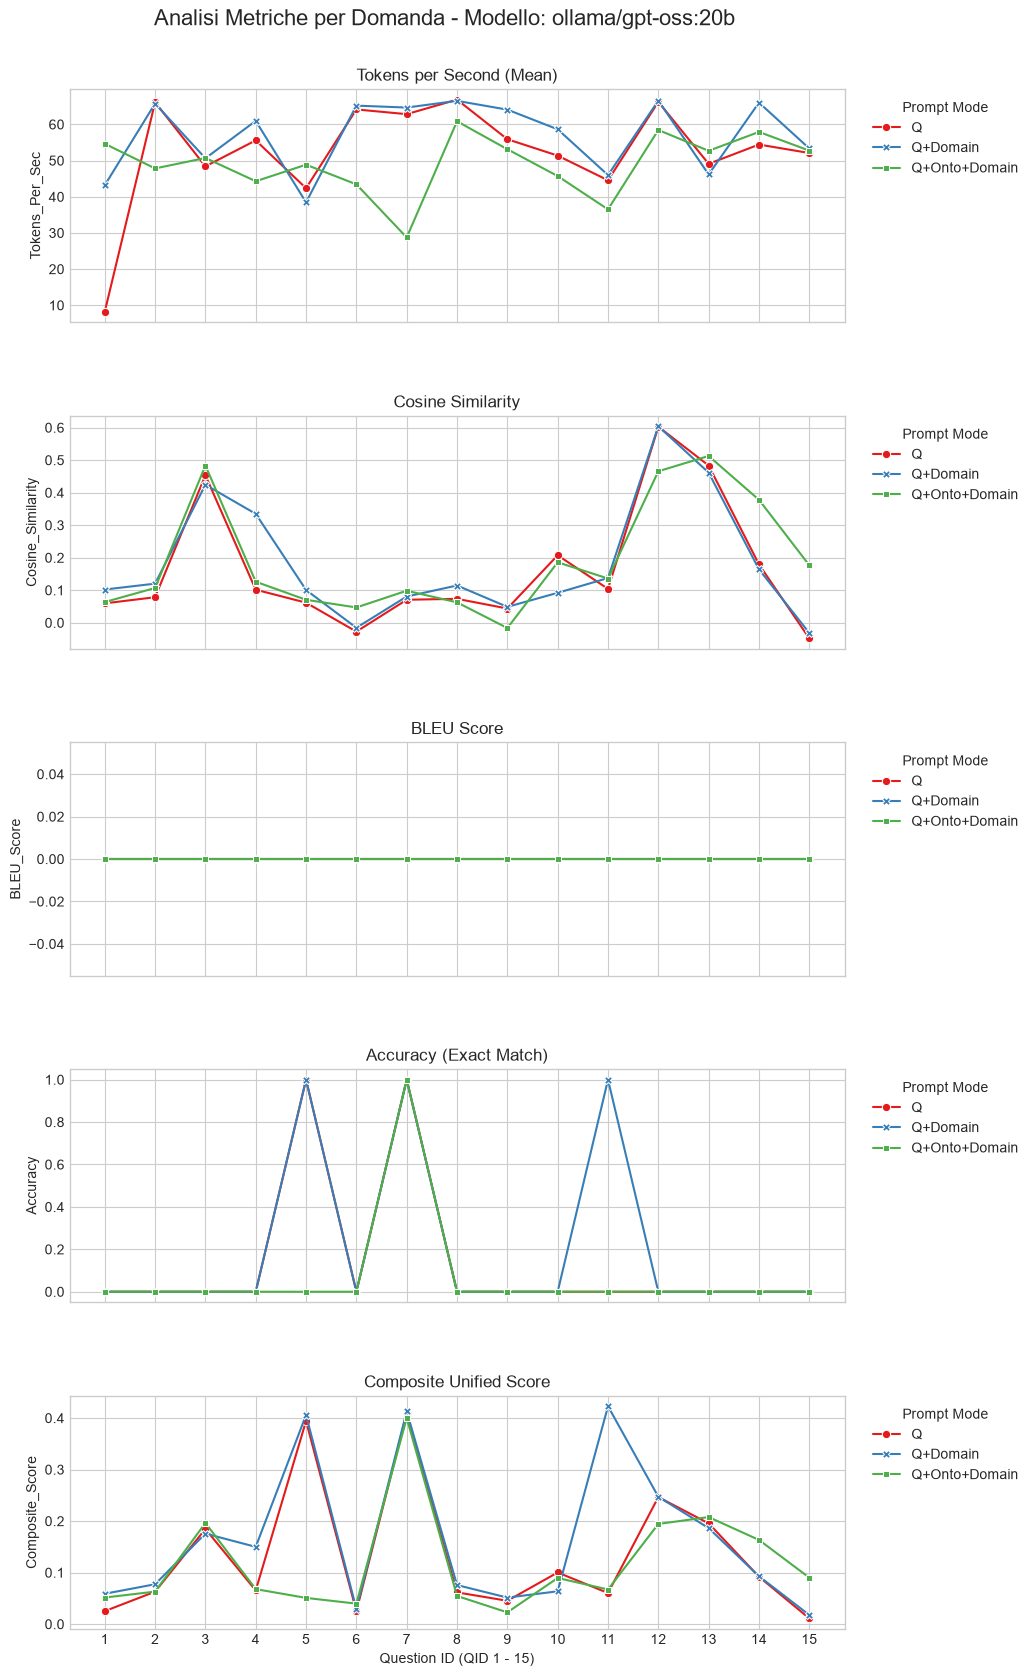

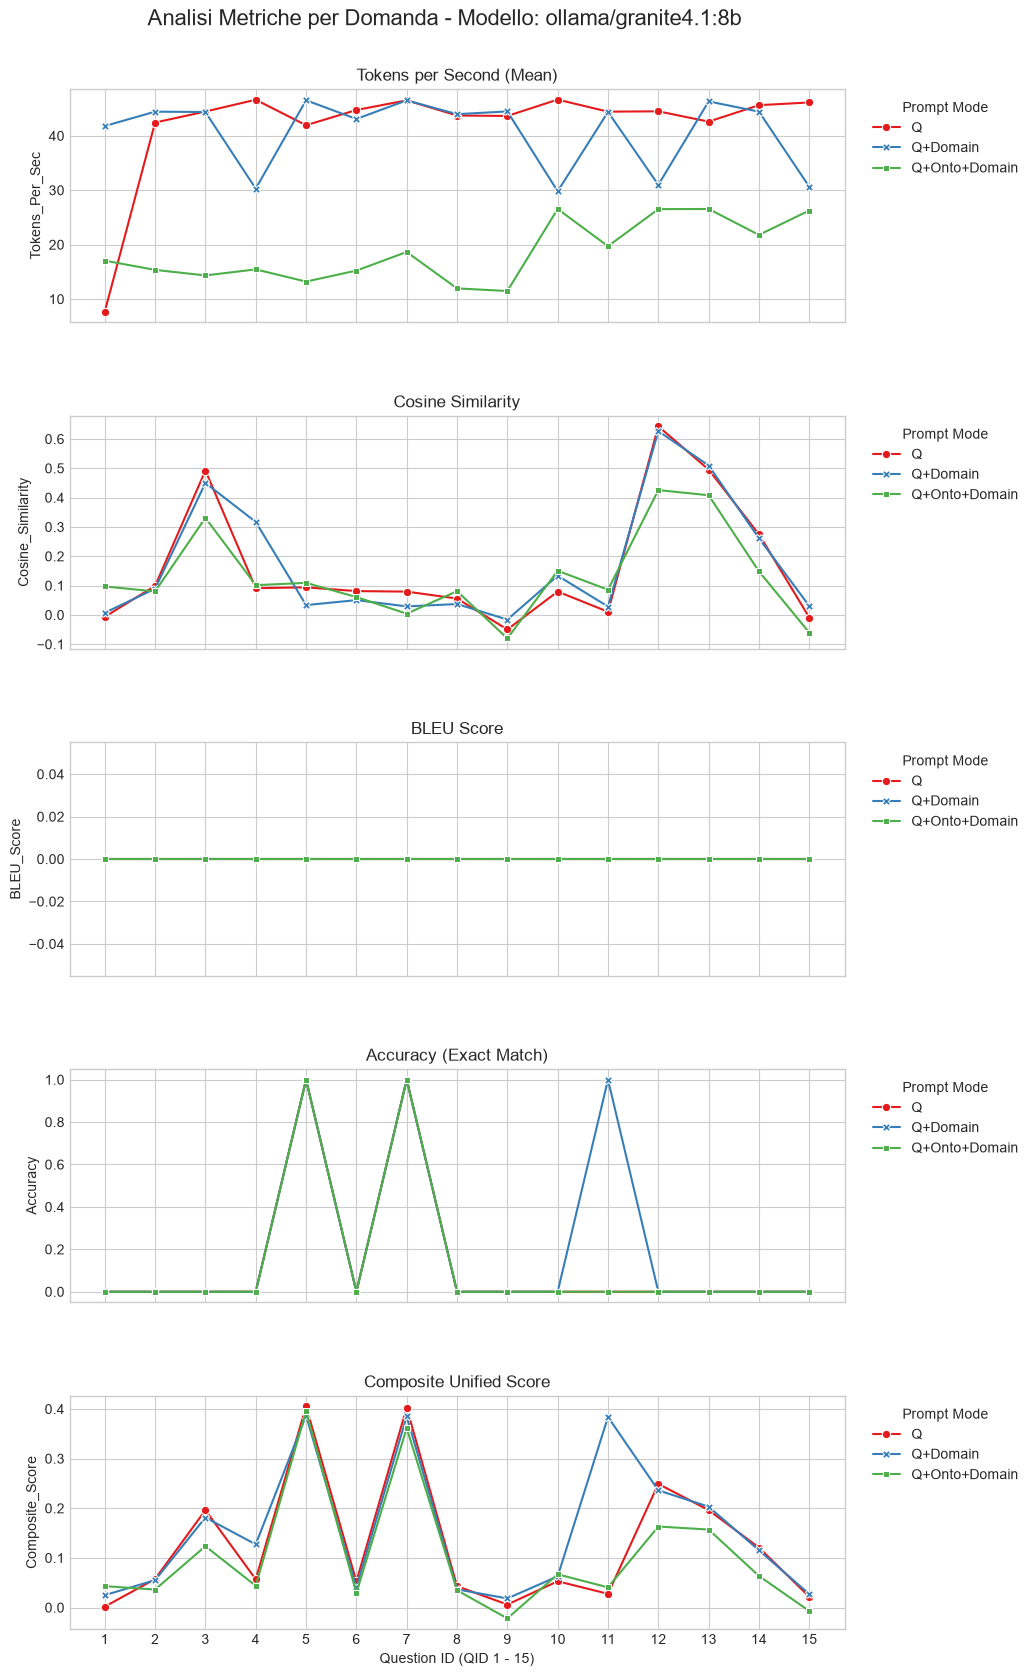

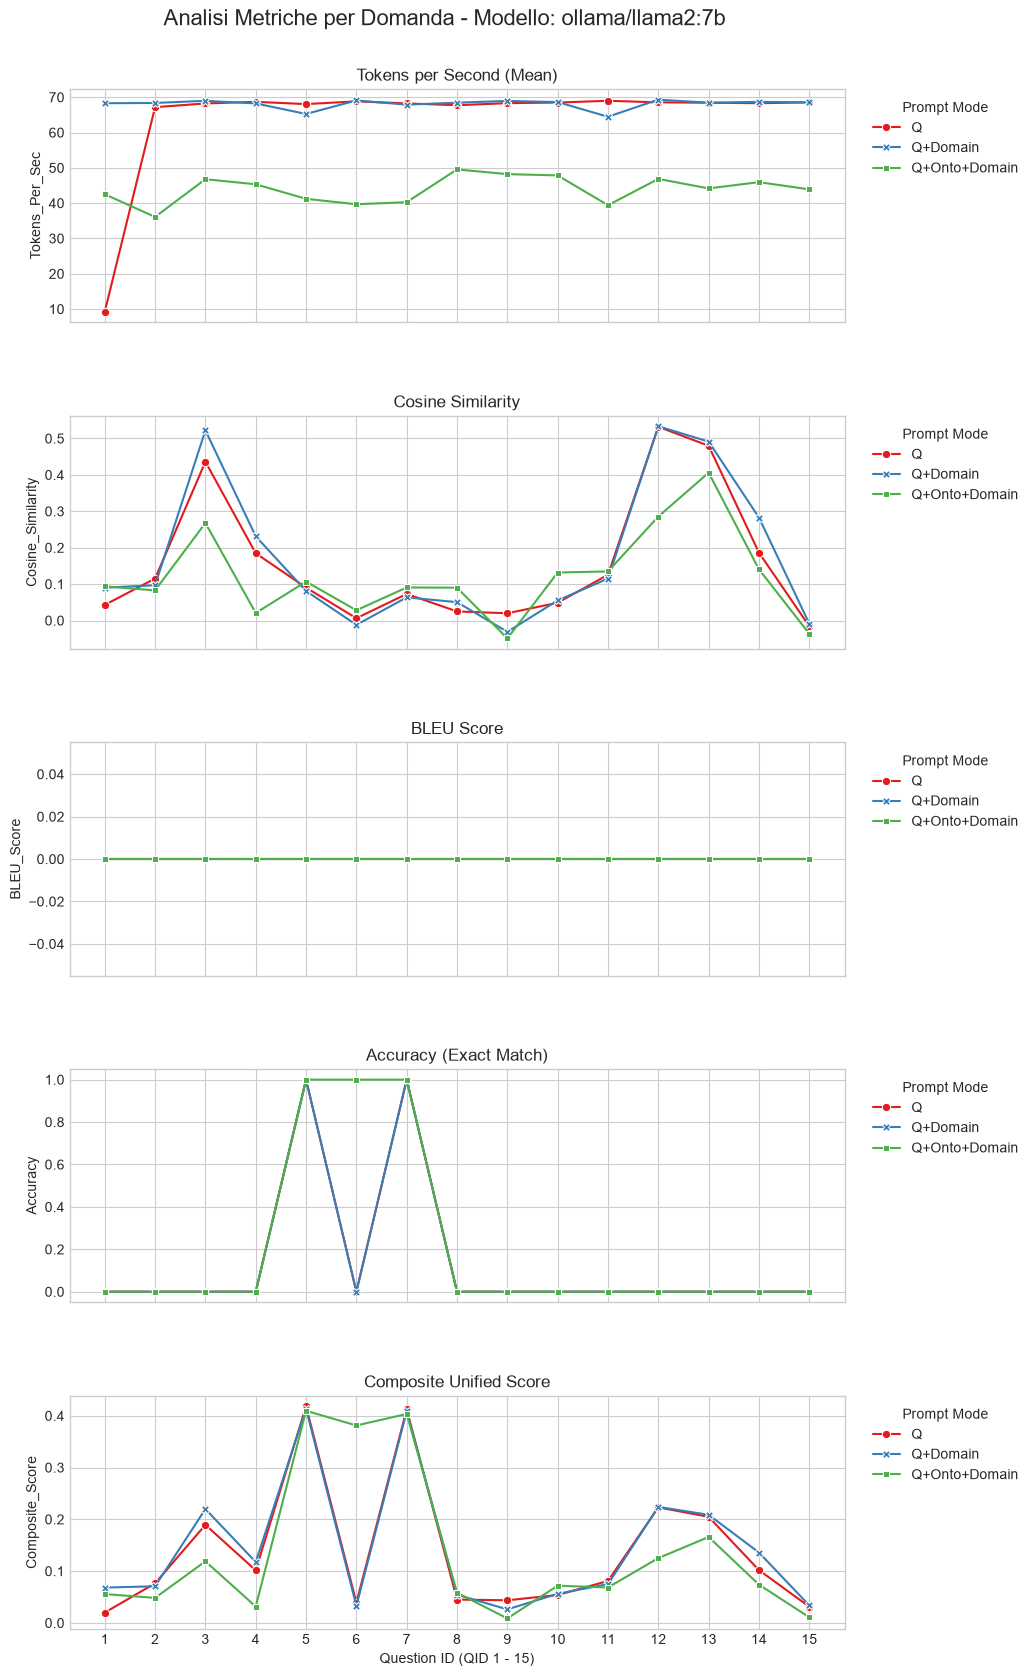

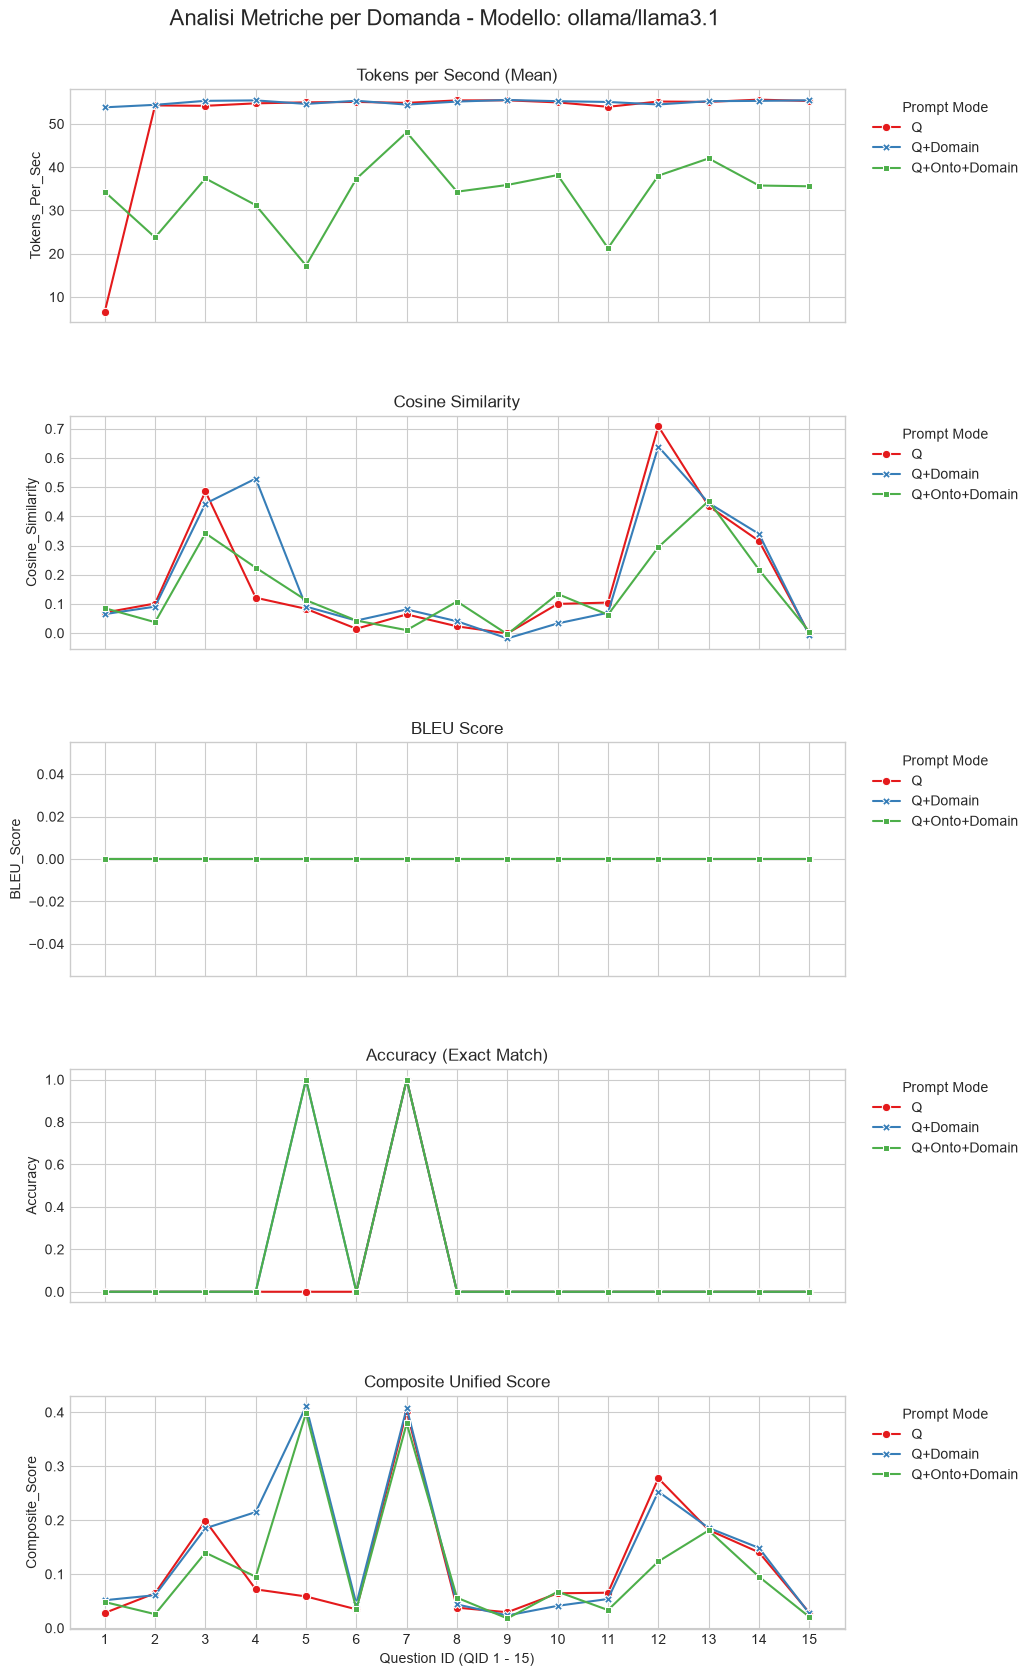

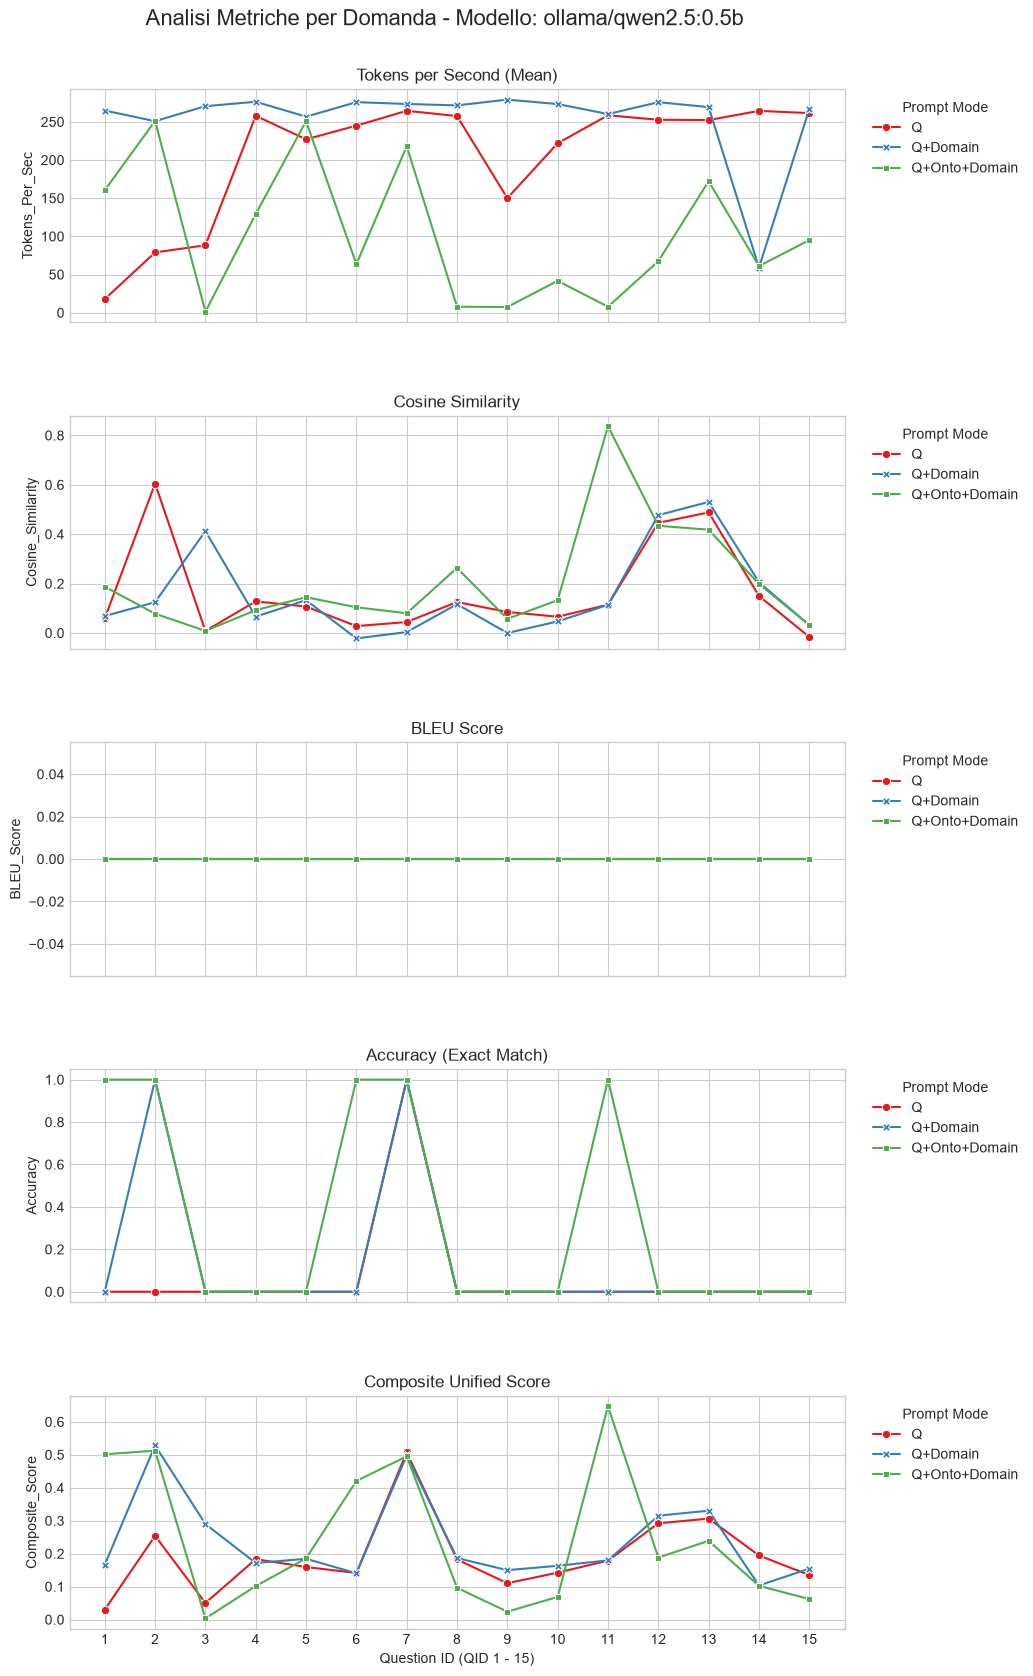

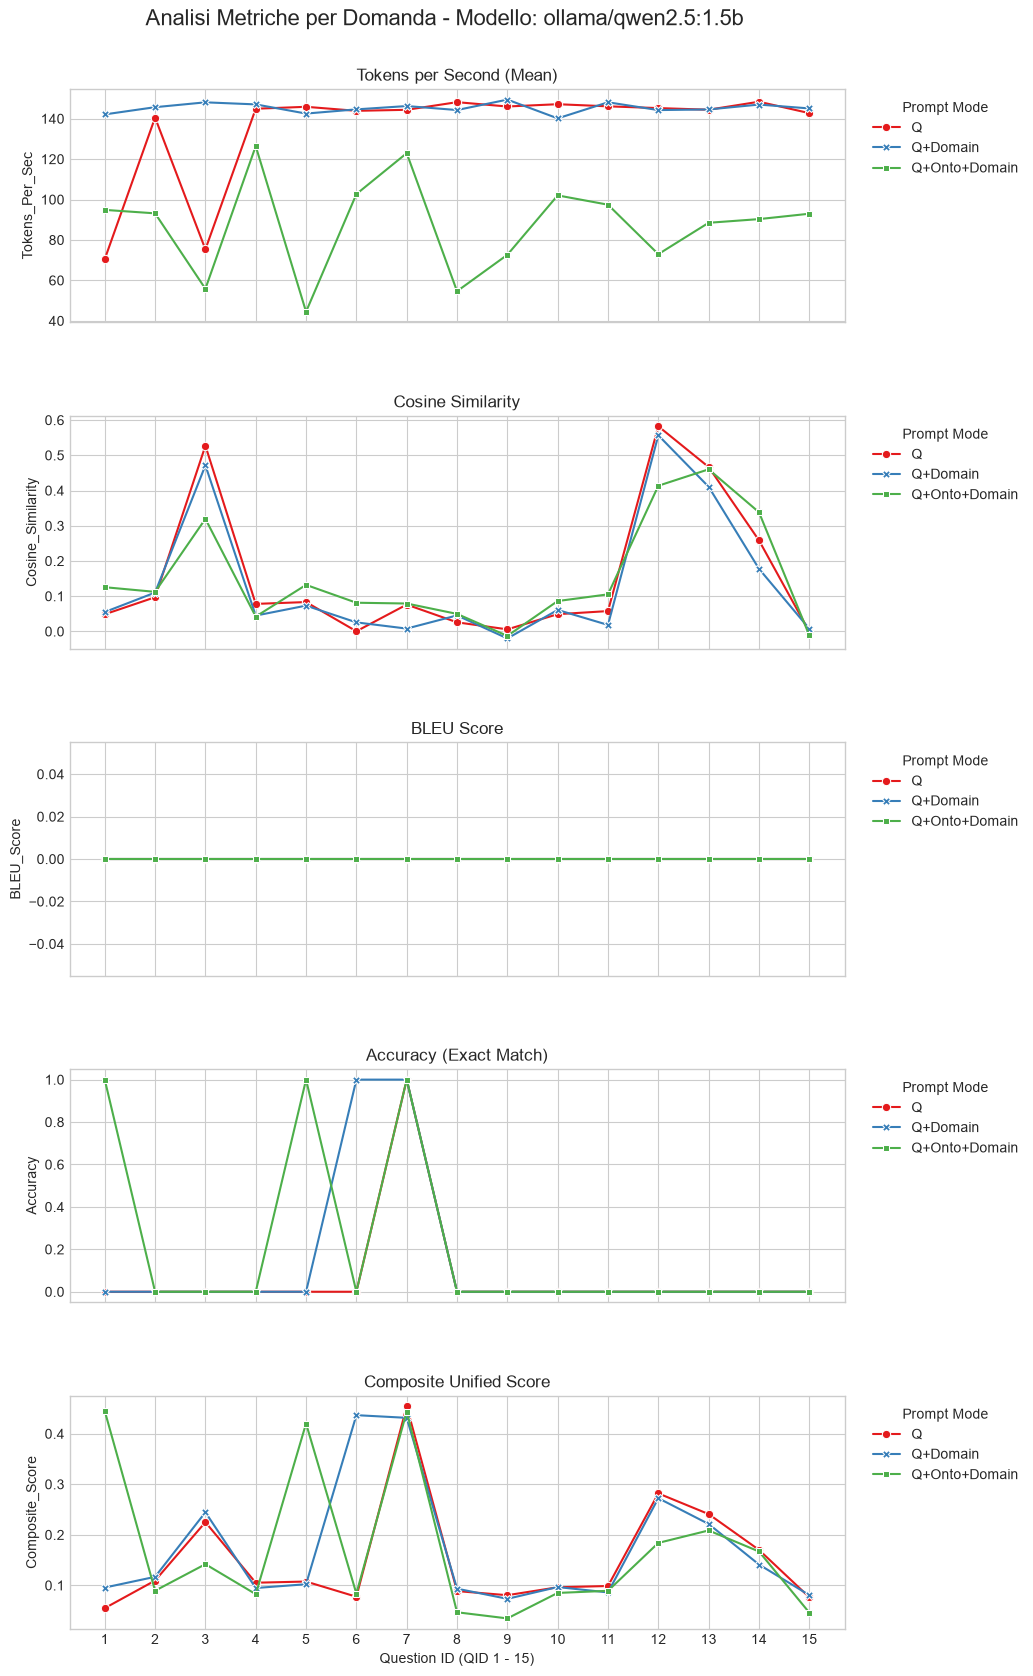

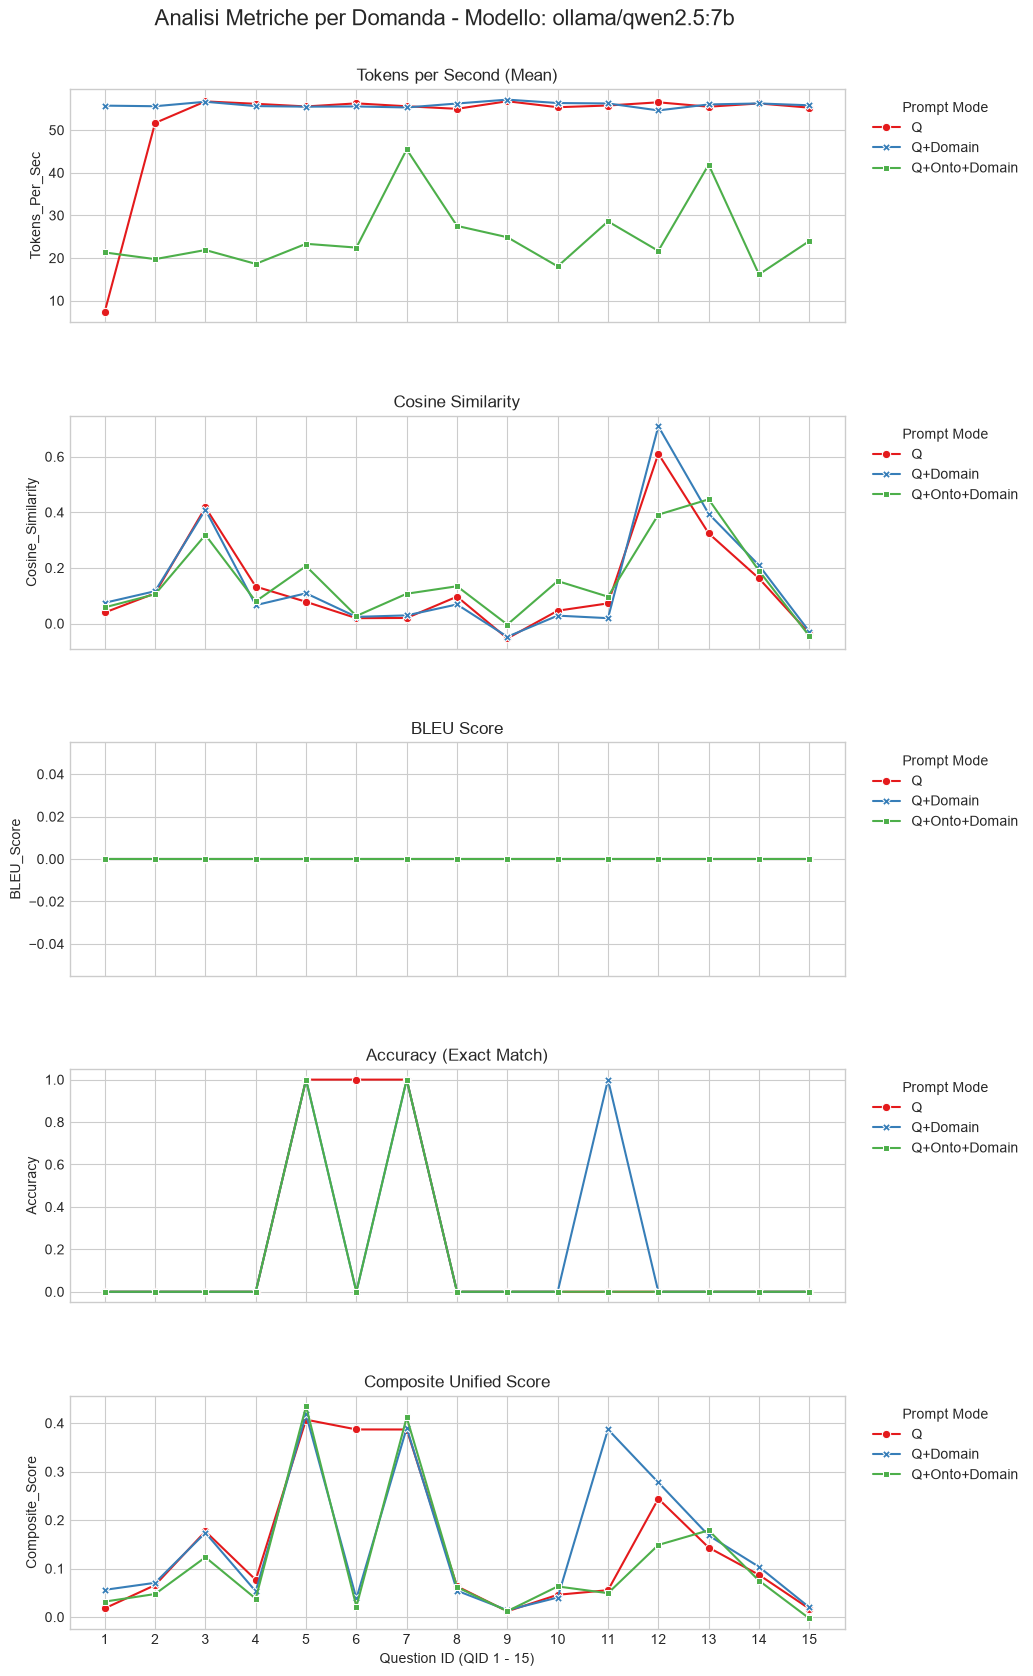

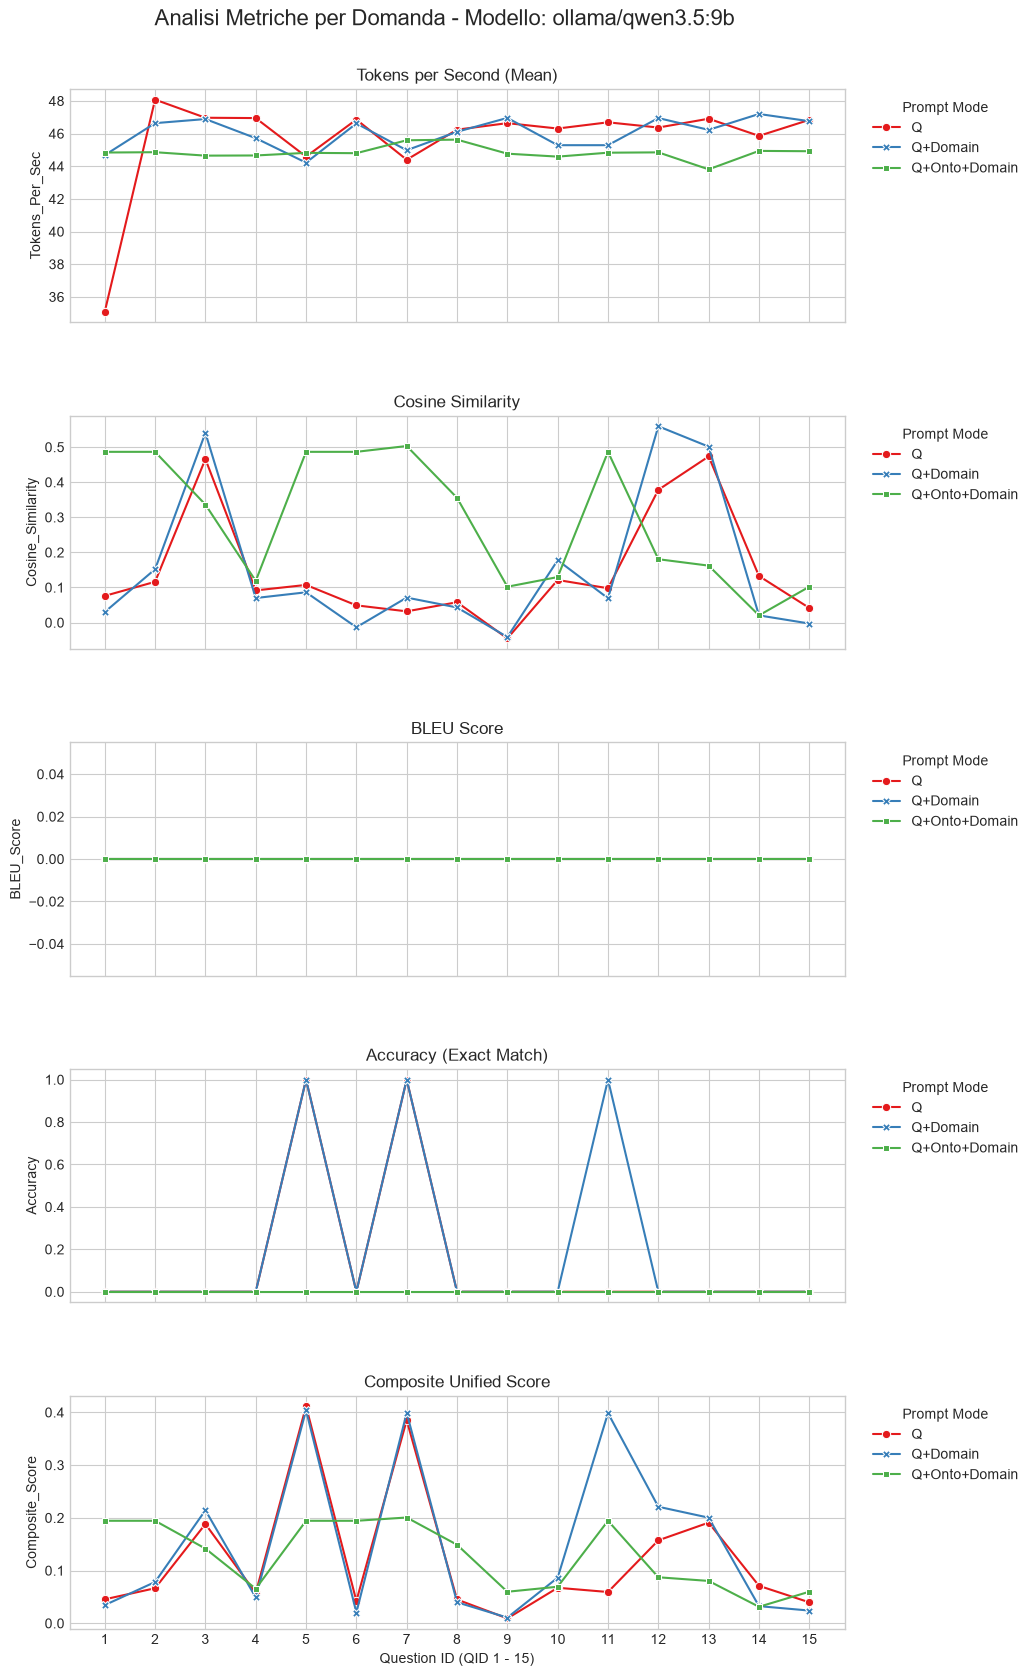

In [9]:
models = df["Model"].unique()
metrics_to_plot = [
    ("Tokens_Per_Sec", "Tokens per Second (Mean)"),
    ("Cosine_Similarity", "Cosine Similarity"),
    ("BLEU_Score", "BLEU Score"),
    ("Accuracy", "Accuracy (Exact Match)"),
    ("Composite_Score", "Composite Unified Score")
]

for model in models:
    df_model = df[df["Model"] == model]
    
    fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)
    fig.suptitle(f"Analisi Metriche per Domanda - Modello: {model}", fontsize=16, y=0.92)
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[idx]
        sns.lineplot(
            data=df_model, x="QID", y=metric, hue="Prompt_Mode", 
            style="Prompt_Mode", markers=True, dashes=False, ax=ax, palette="Set1"
        )
        ax.set_title(title, fontsize=12)
        ax.set_ylabel(metric)
        ax.set_xticks(range(1, 16))
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Prompt Mode")
        
    plt.xlabel("Question ID (QID 1 - 15)")
    fig.subplots_adjust(top=0.88, hspace=0.4)
    plt.show()

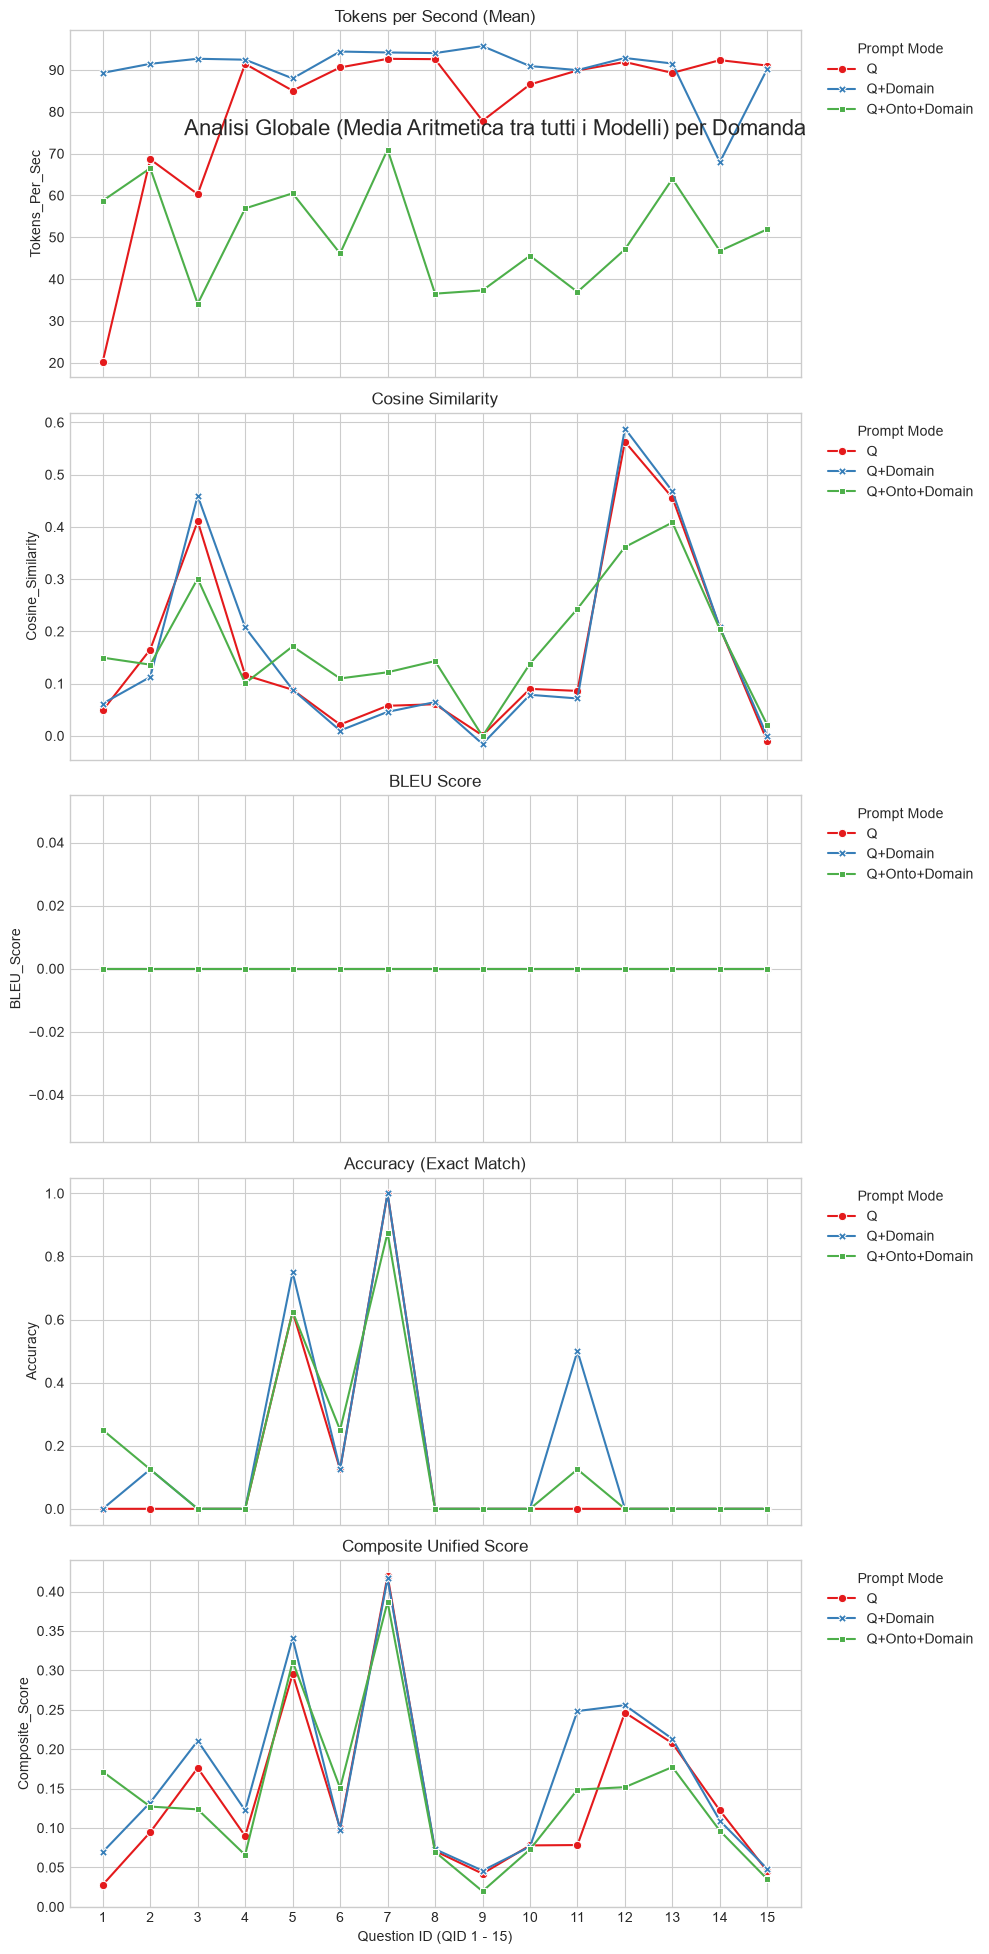

In [ ]:
# Media tra modelli raggruppando per Prompt_Mode e QID
df_part2 = df.groupby(["Prompt_Mode", "QID"])[["Tokens_Per_Sec", "Cosine_Similarity", "BLEU_Score", "Accuracy", "Composite_Score"]].mean().reset_index()

fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)
fig.suptitle("Analisi Globale (Media Aritmetica tra tutti i Modelli) per Domanda", fontsize=16, y=0.92)

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx]
    sns.lineplot(
        data=df_part2, x="QID", y=metric, hue="Prompt_Mode", 
        style="Prompt_Mode", markers=True, dashes=False, ax=ax, palette="Set1"
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks(range(1, 16))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Prompt Mode")

plt.xlabel("Question ID (QID 1 - 15)")
fig.subplots_adjust(top=0.88, hspace=0.4)
plt.show()

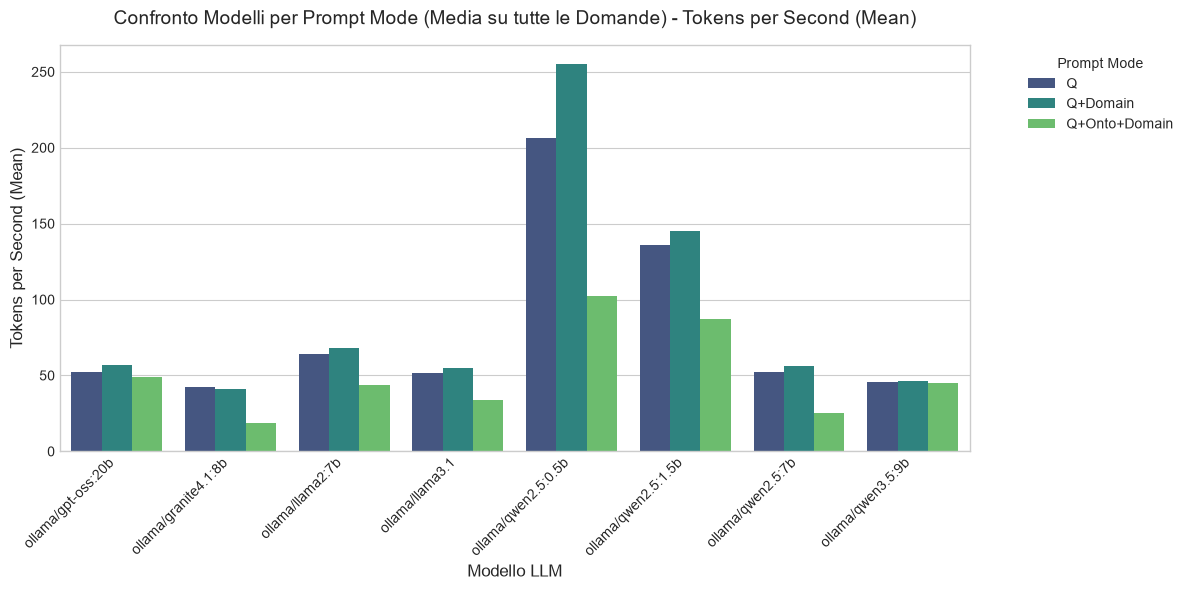

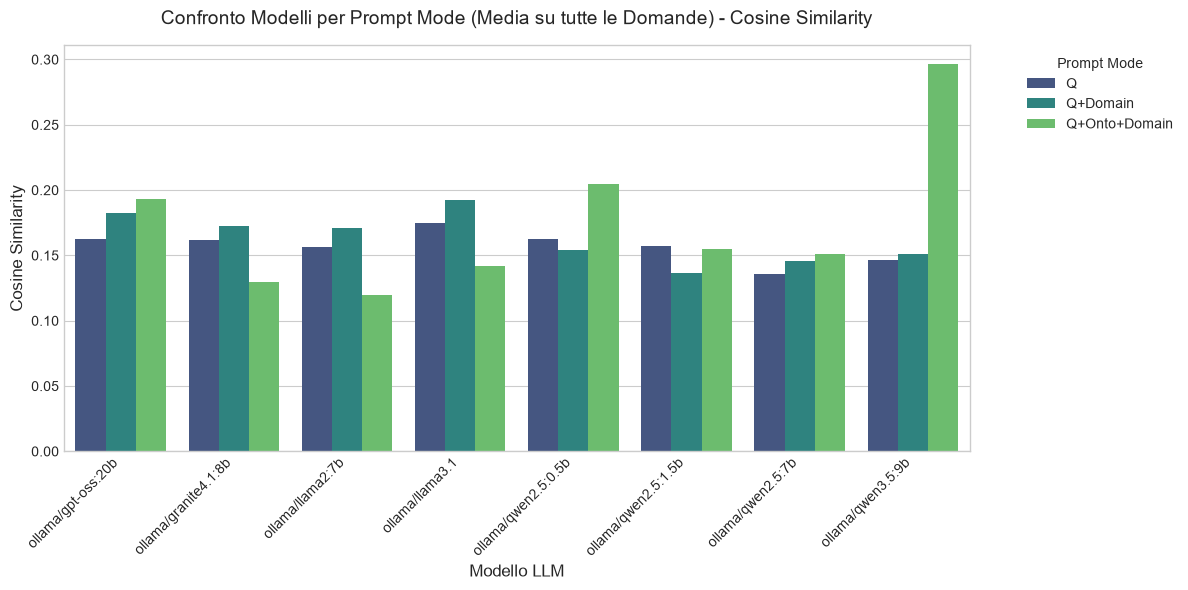

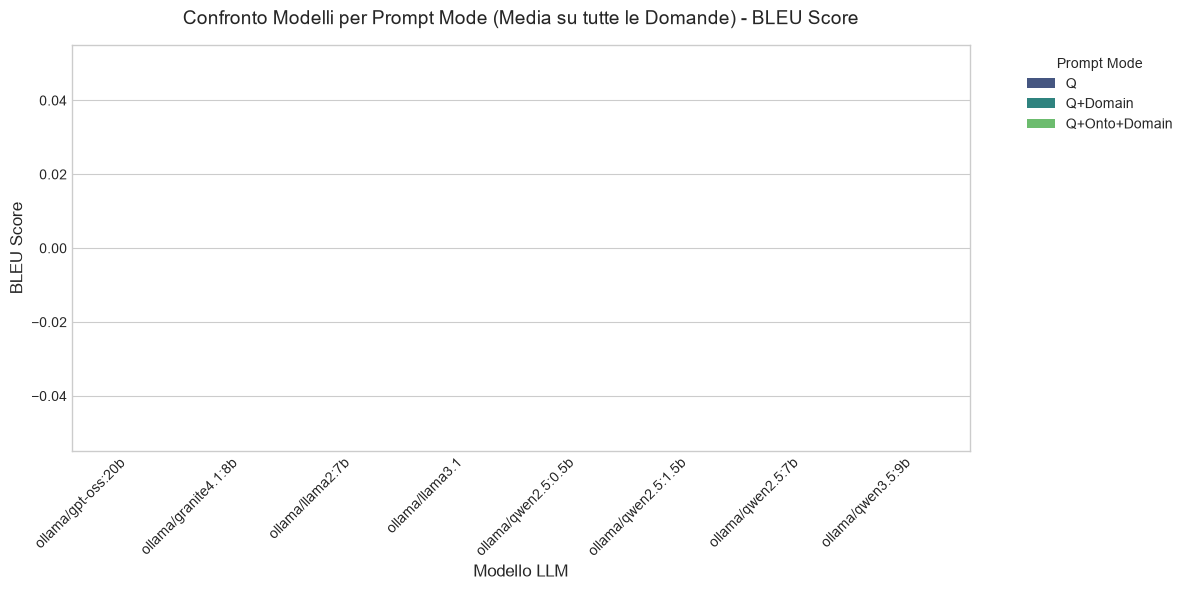

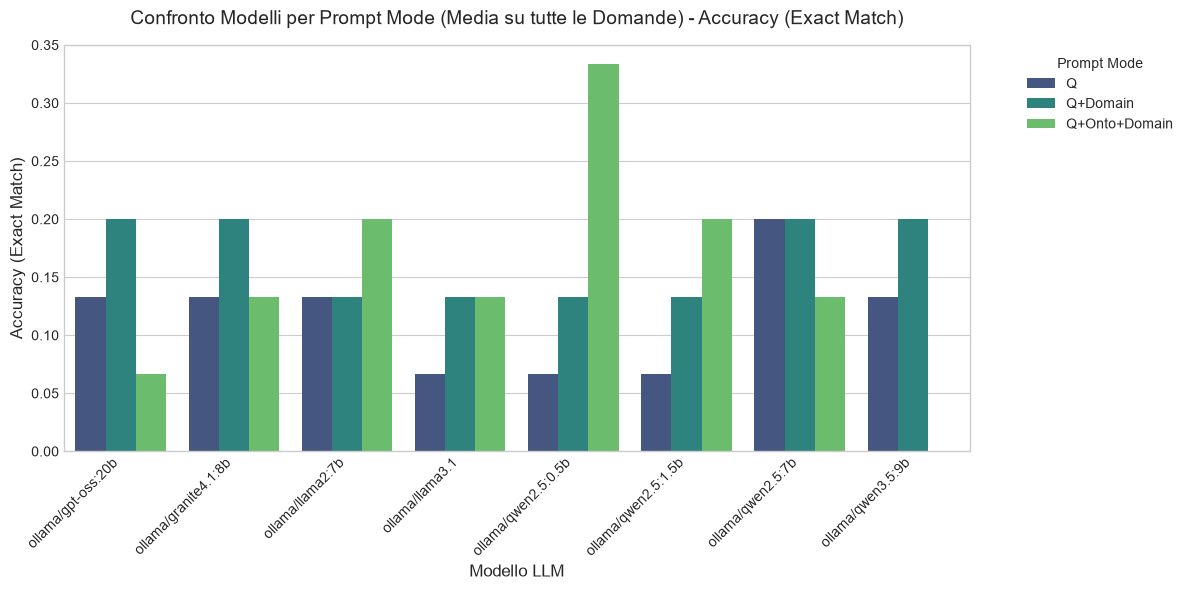

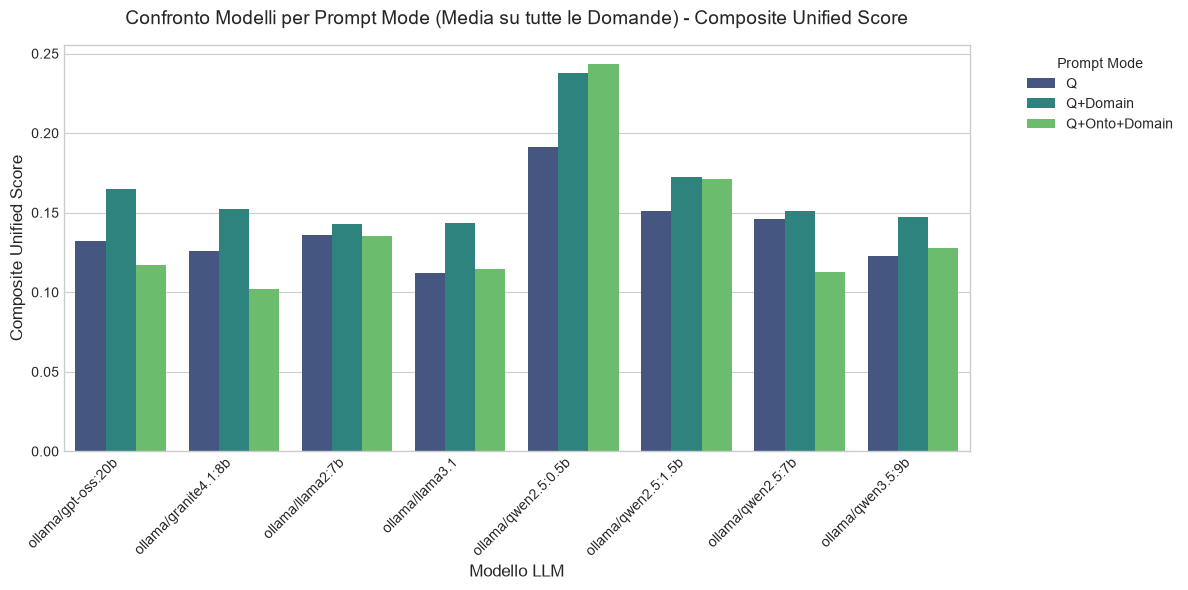

In [6]:
# Media tra domande raggruppando per Model e Prompt_Mode
df_part3 = df.groupby(["Model", "Prompt_Mode"])[["Tokens_Per_Sec", "Cosine_Similarity", "BLEU_Score", "Accuracy", "Composite_Score"]].mean().reset_index()

for metric, title in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_part3, x="Model", y=metric, hue="Prompt_Mode", palette="viridis"
    )
    plt.title(f"Confronto Modelli per Prompt Mode (Media su tutte le Domande) - {title}", fontsize=14, pad=15)
    plt.xlabel("Modello LLM", fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Prompt Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

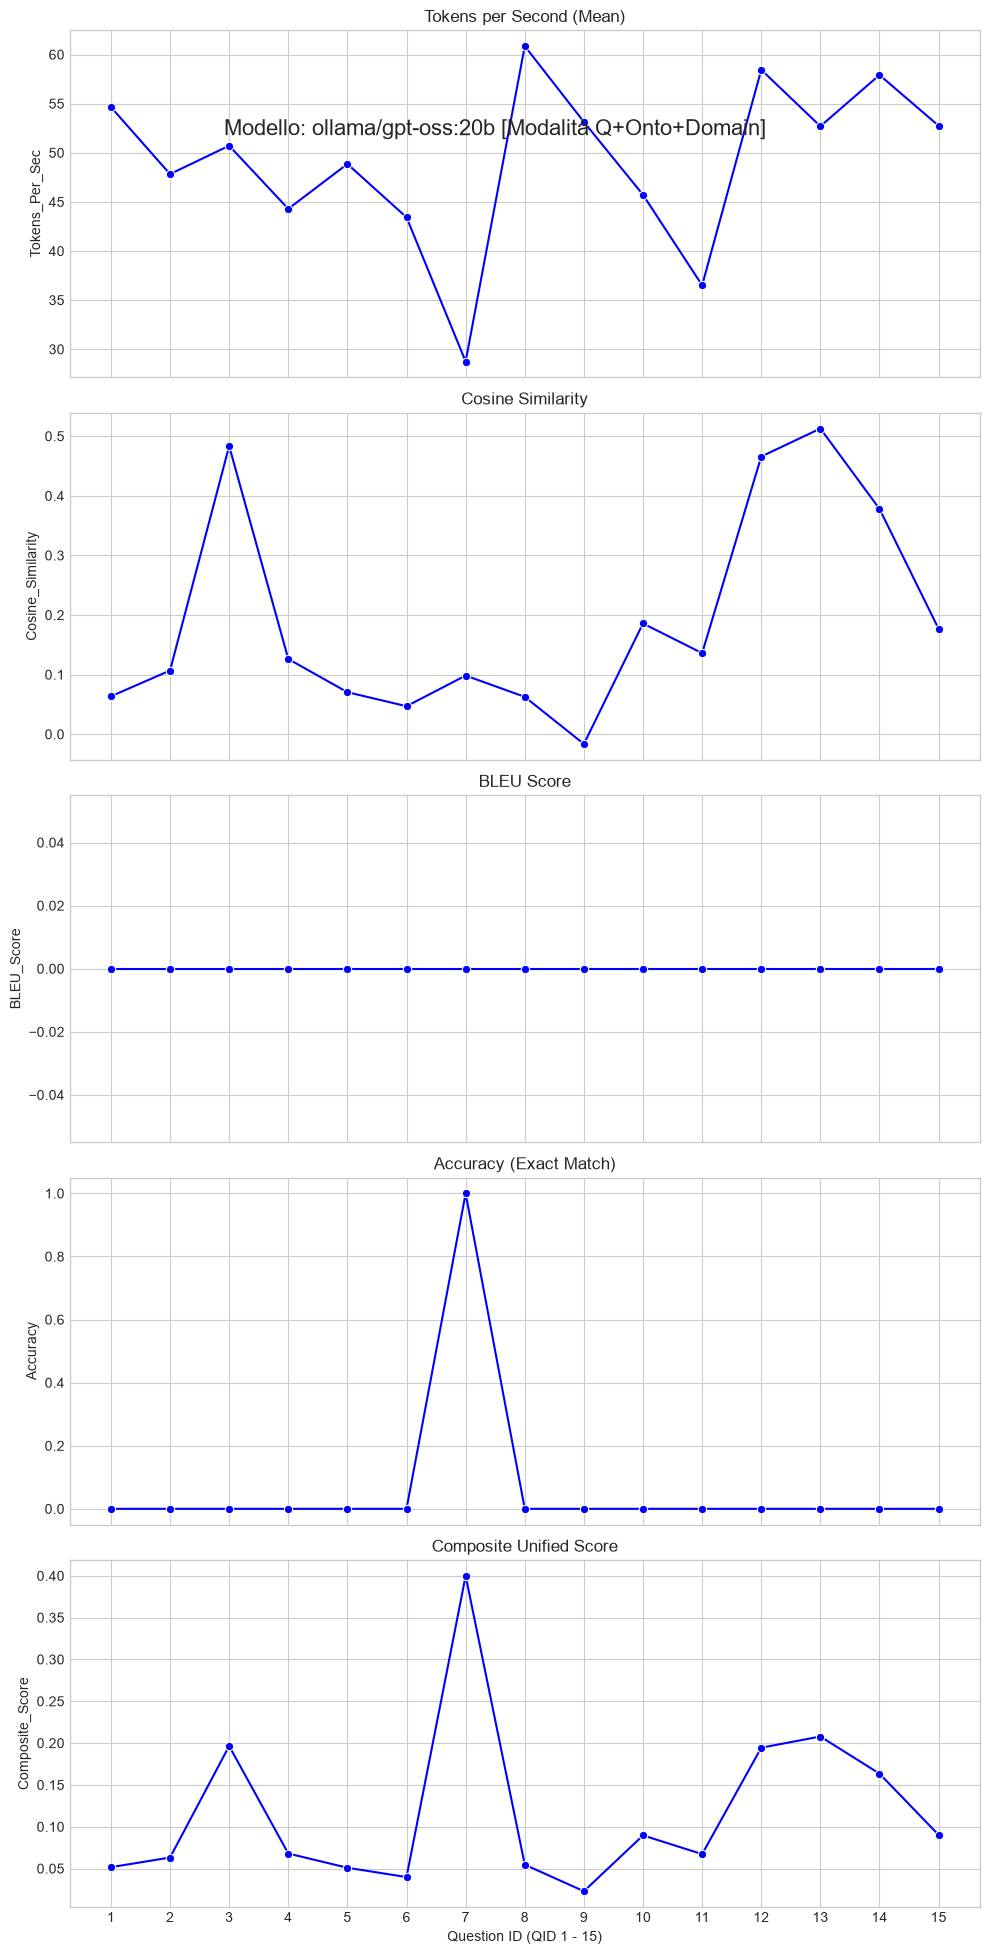

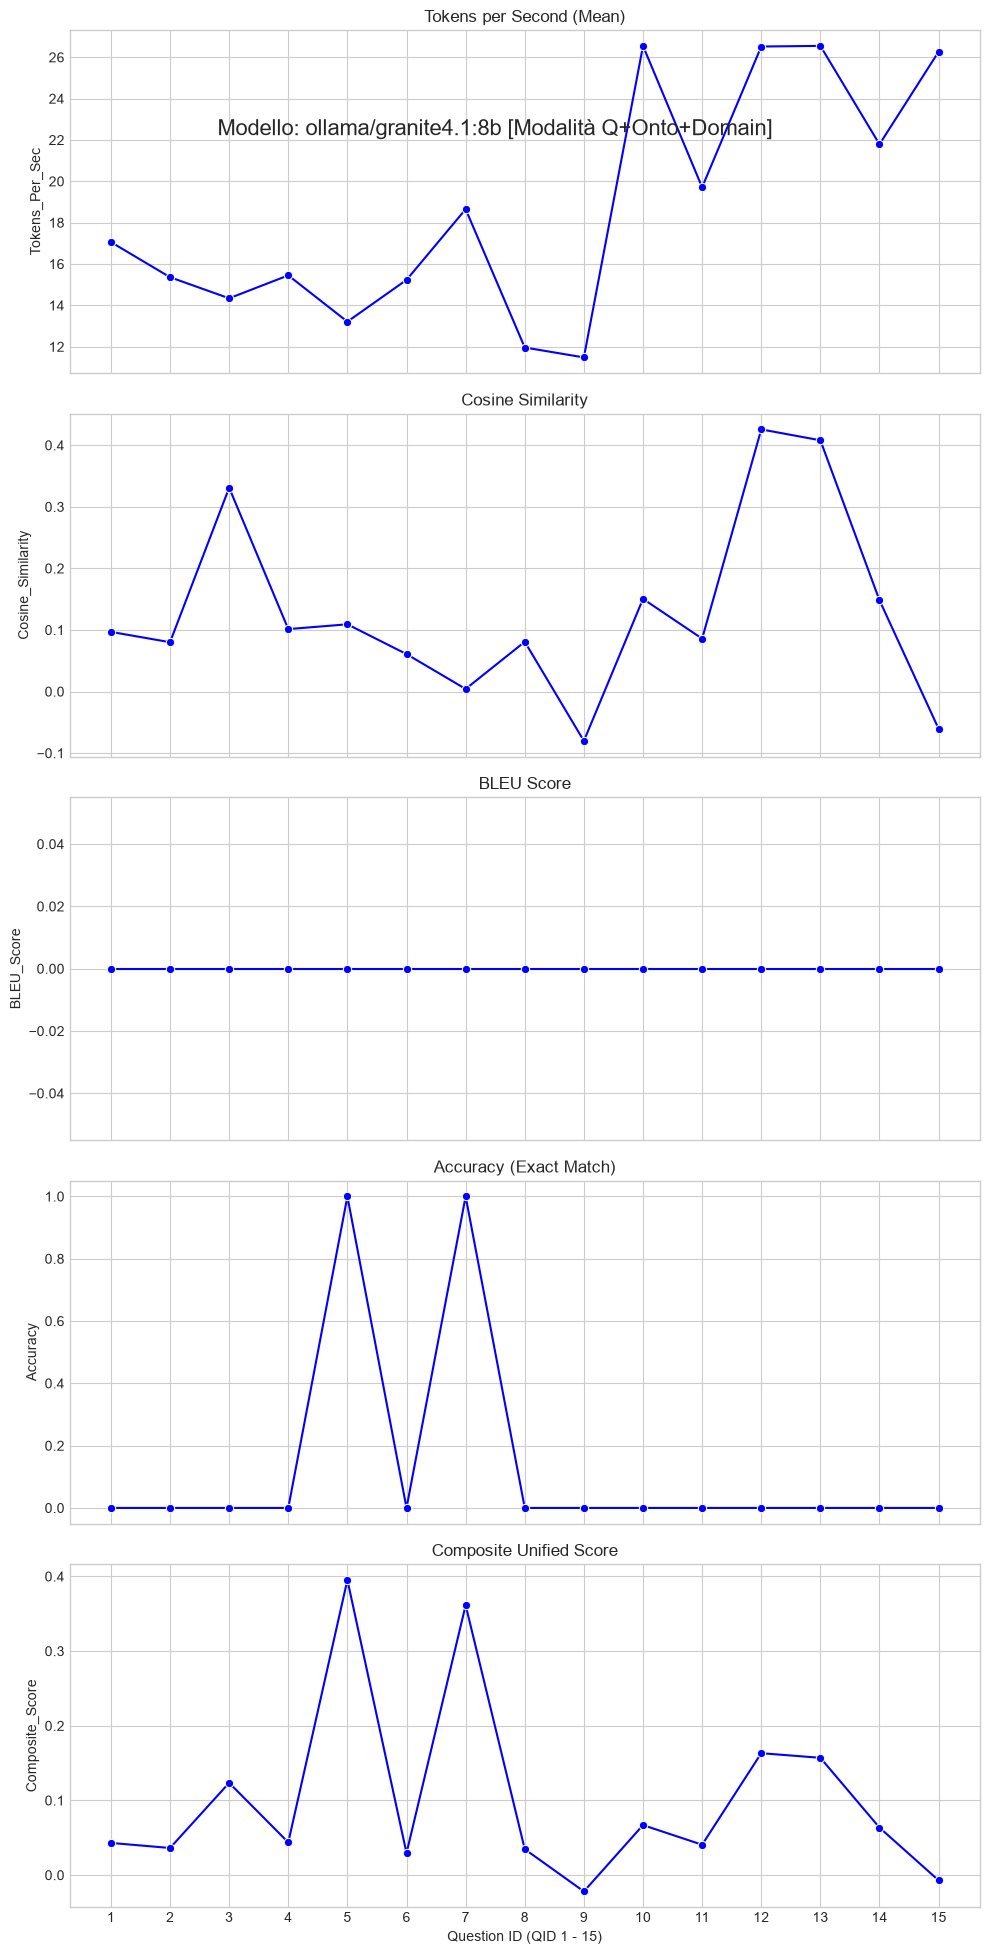

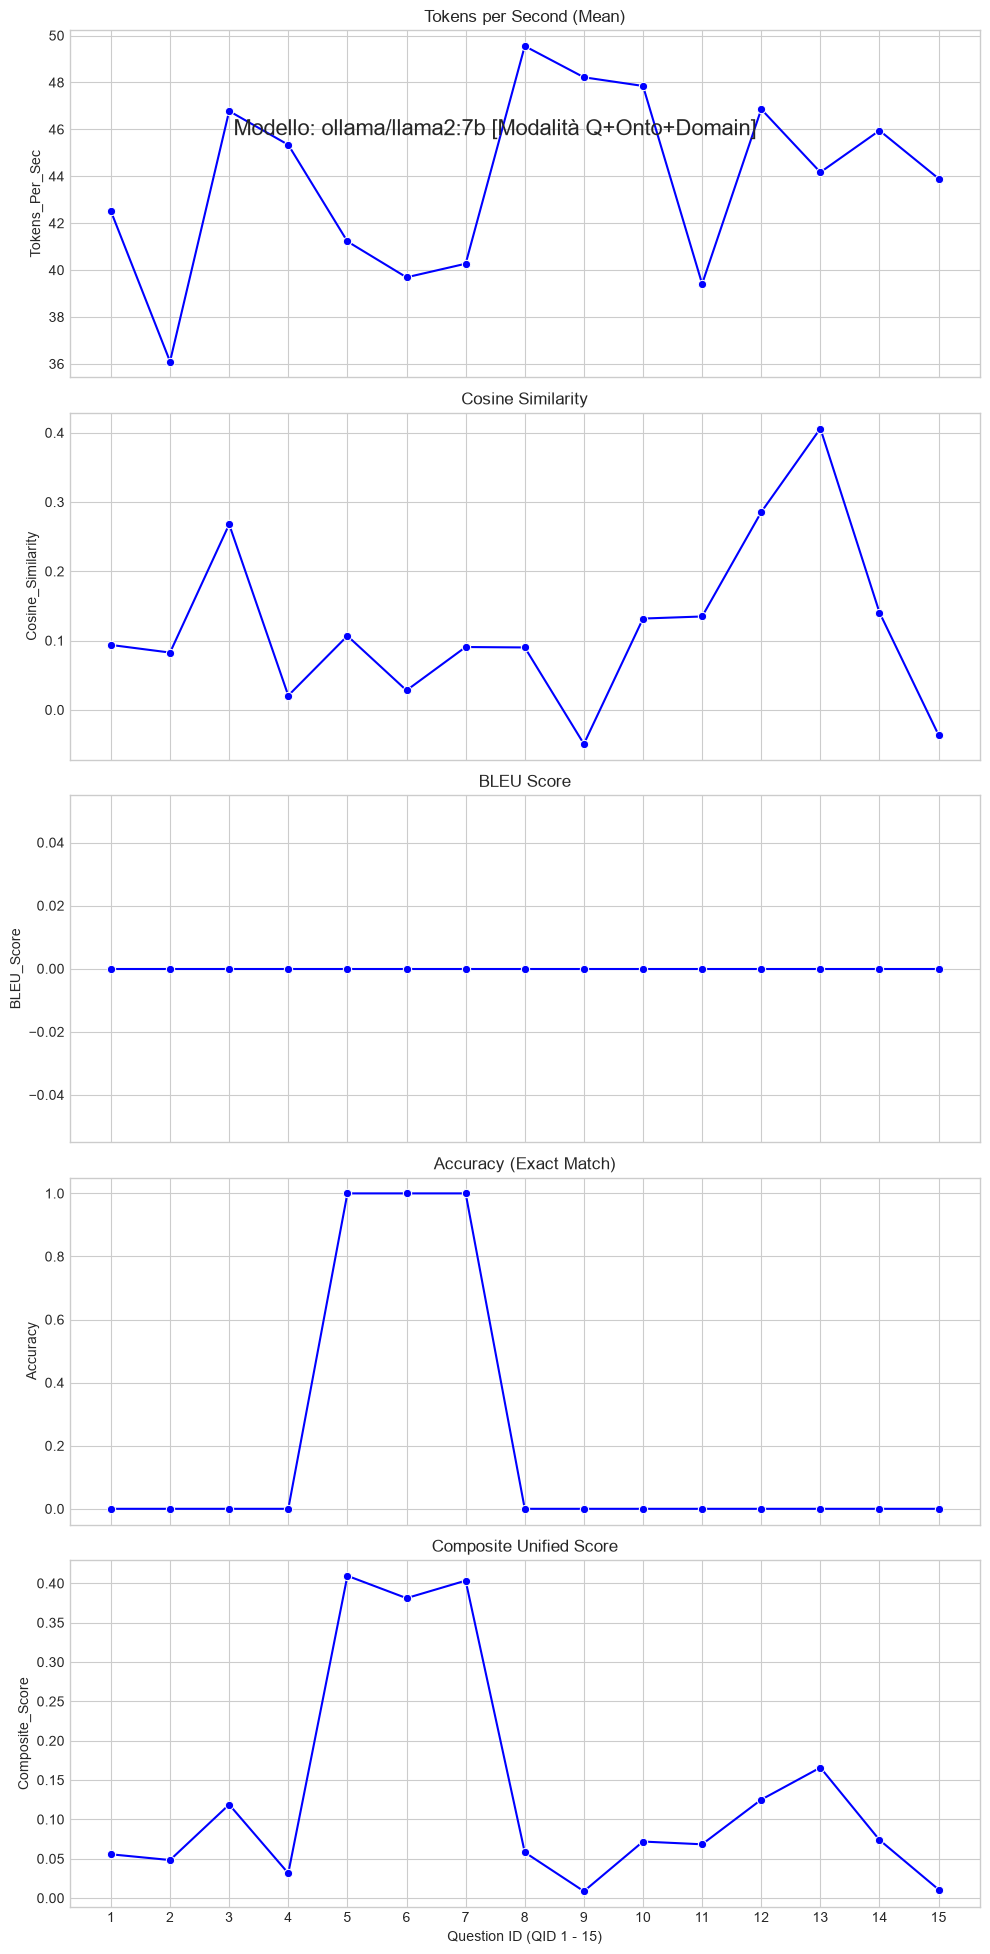

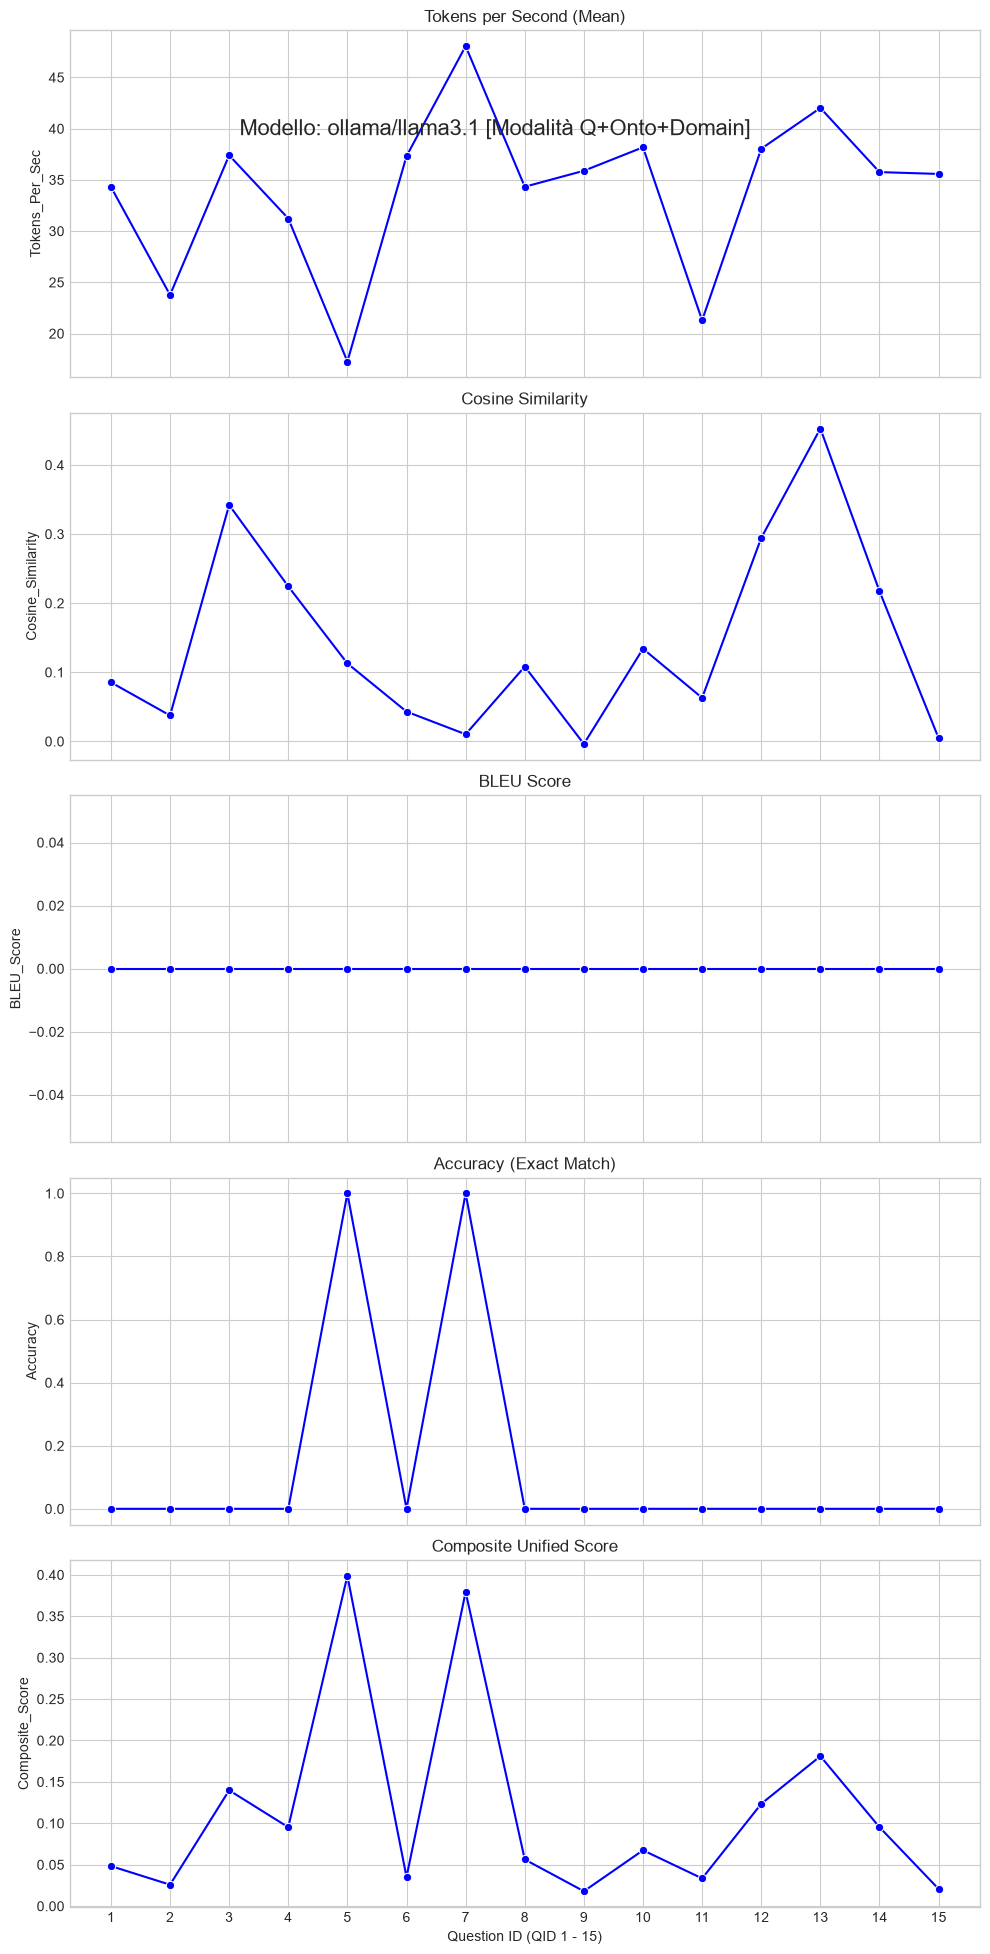

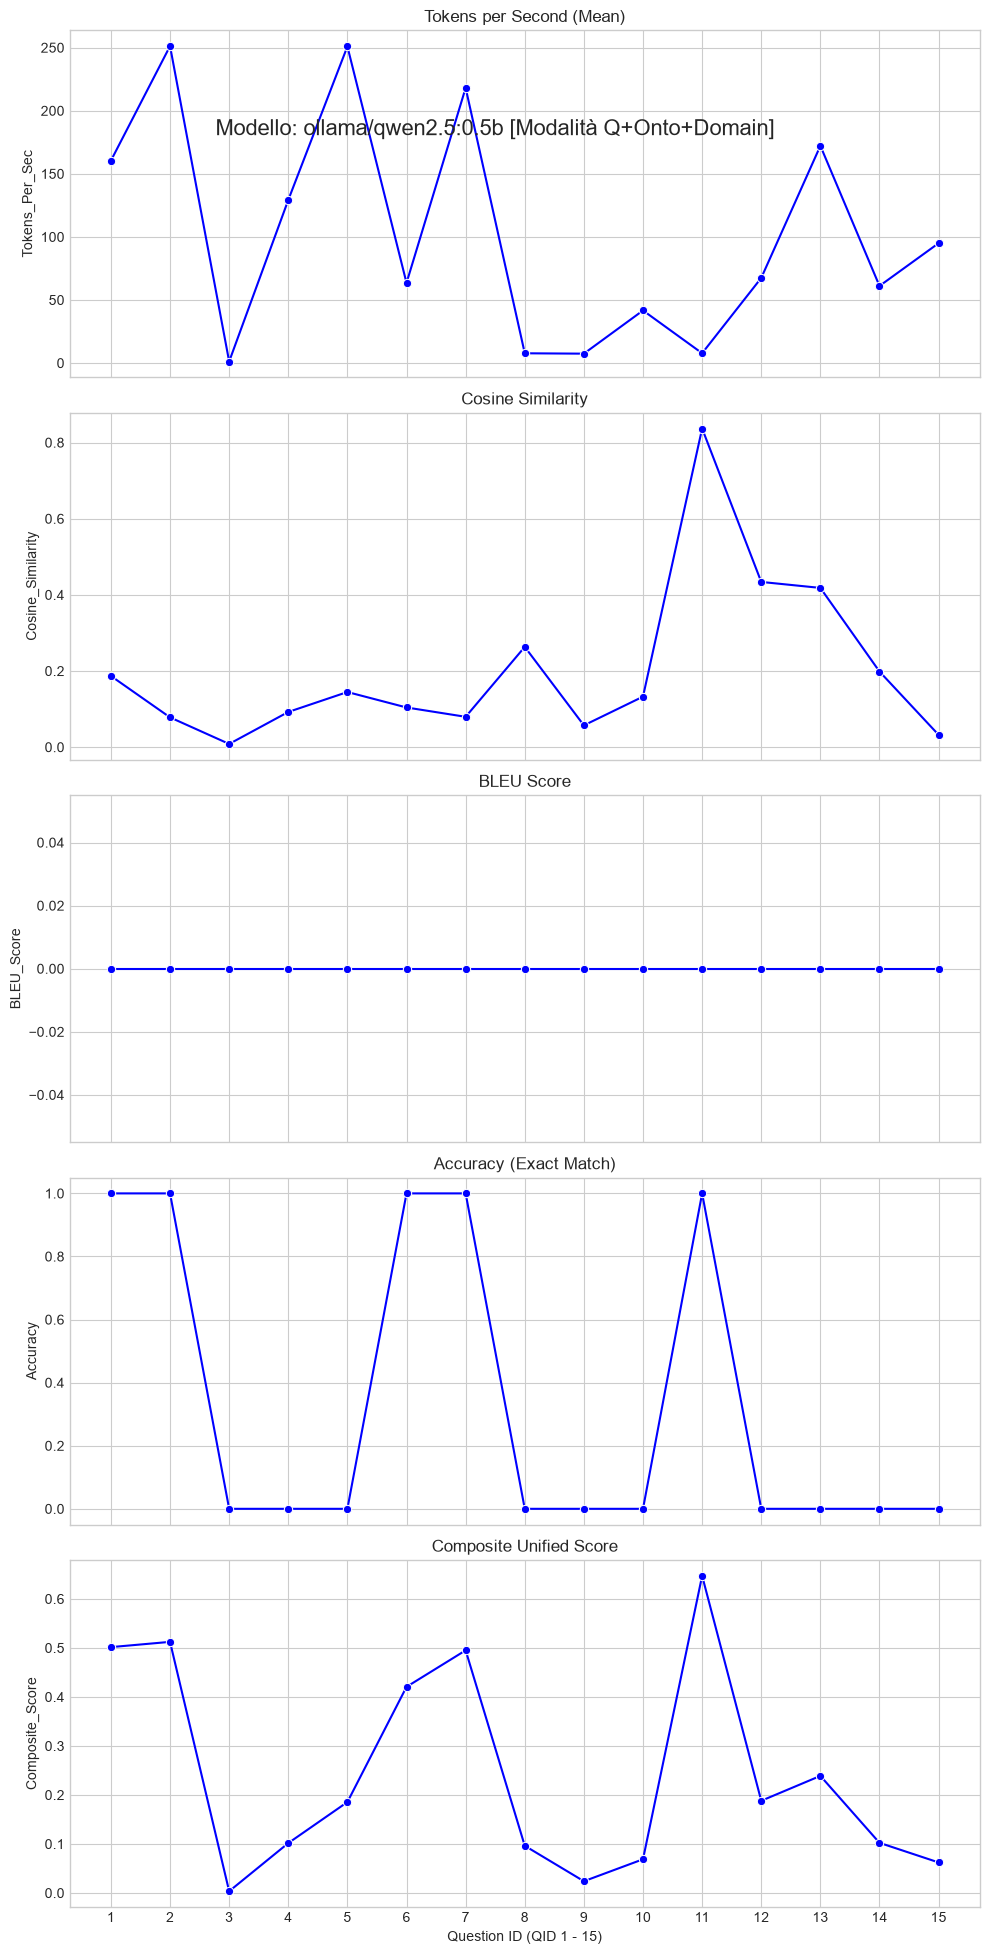

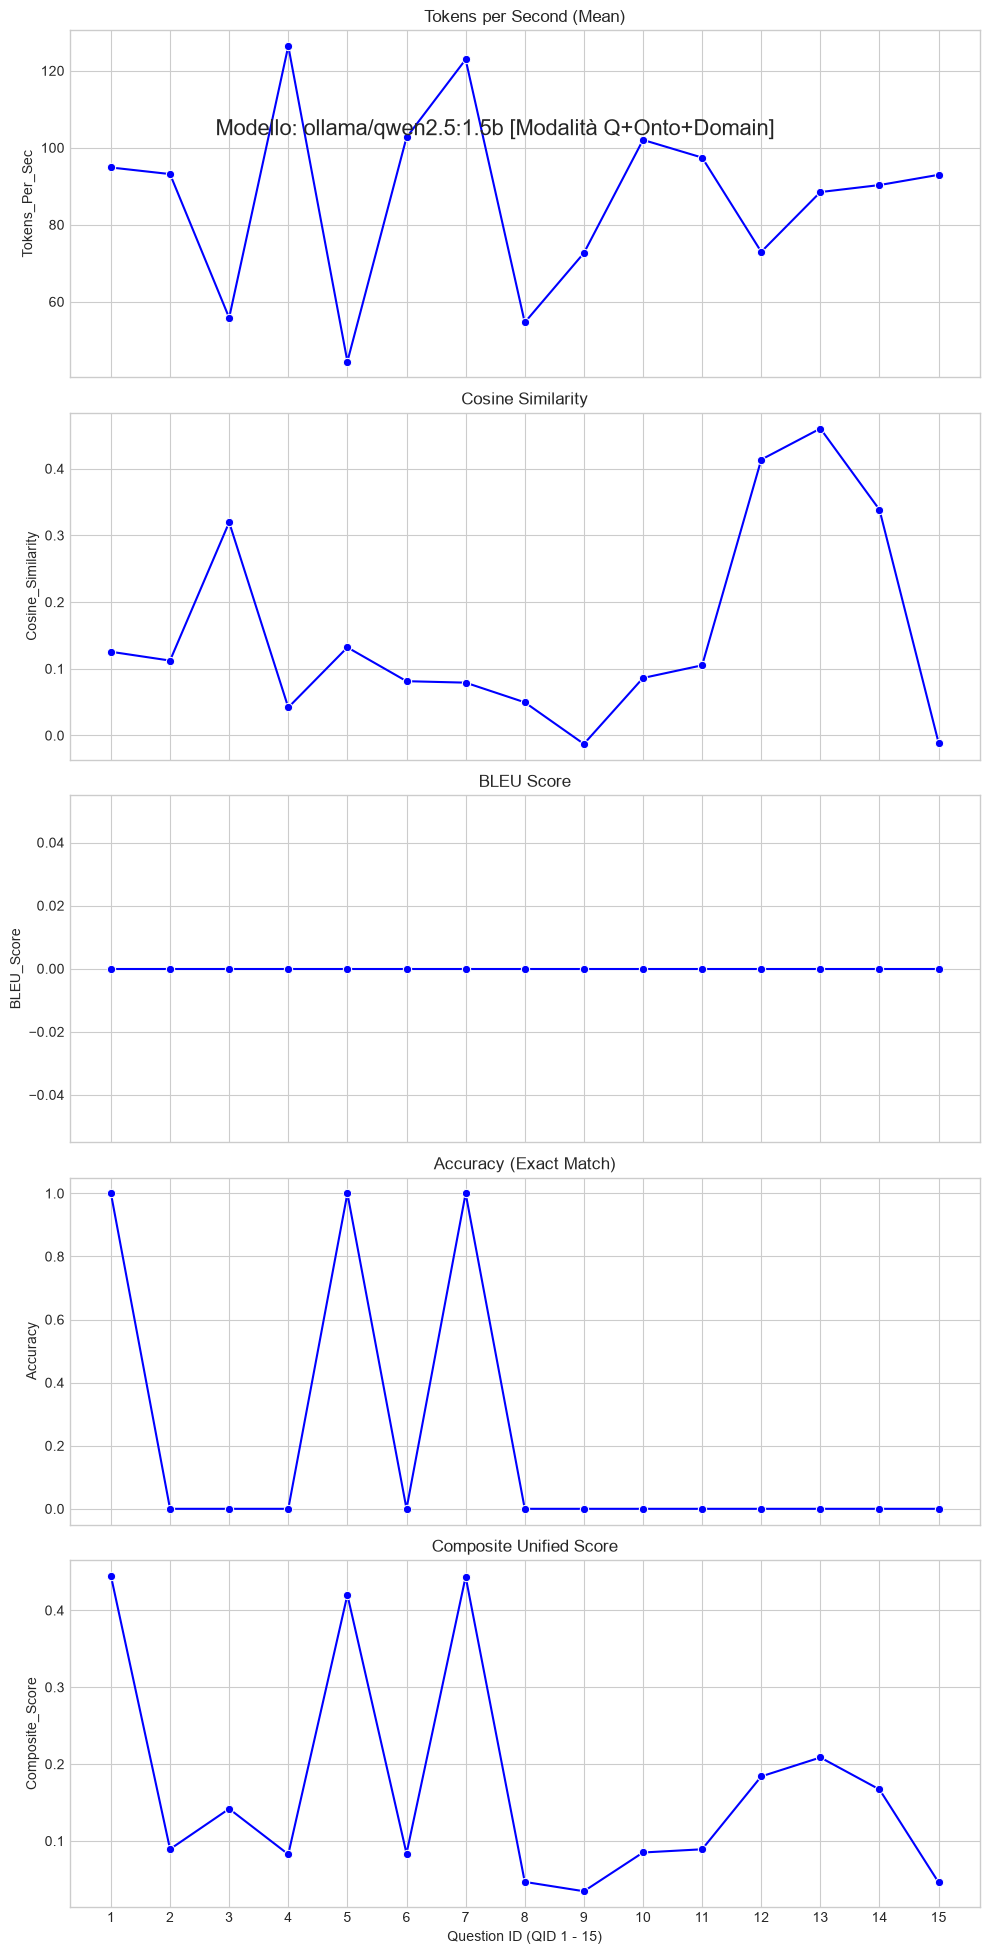

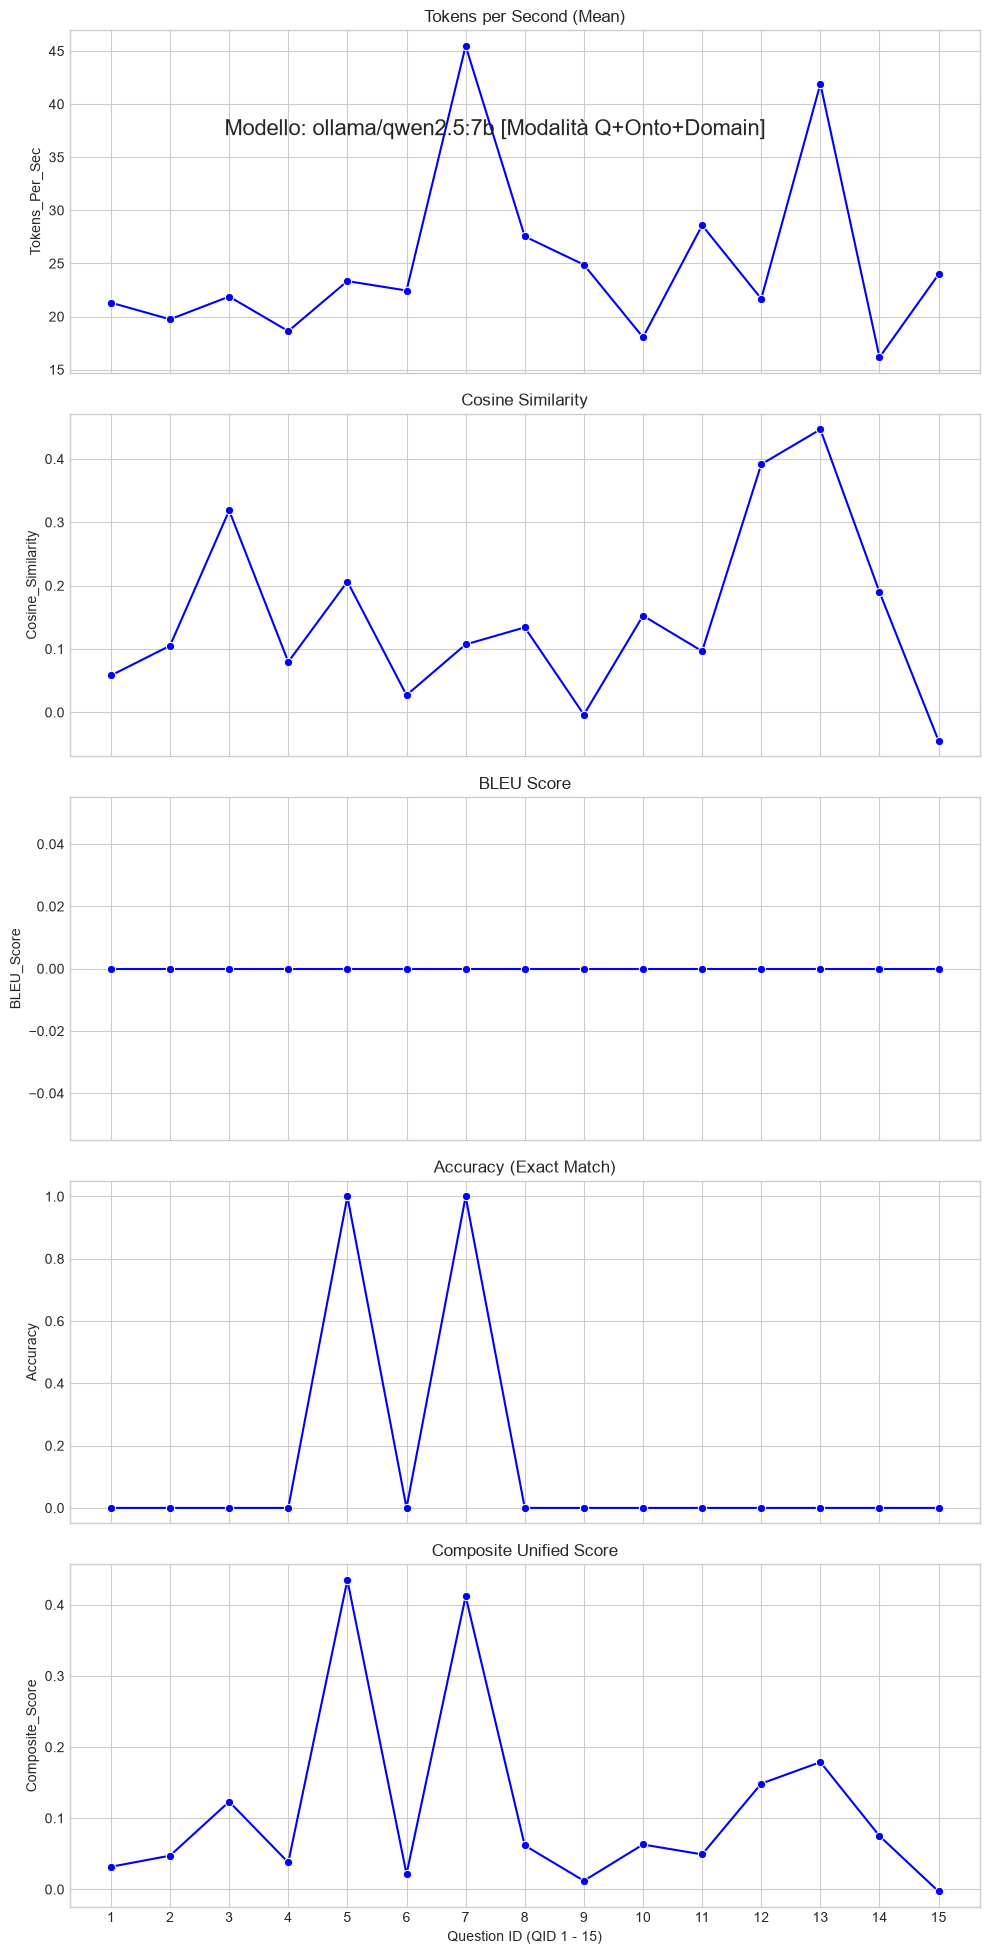

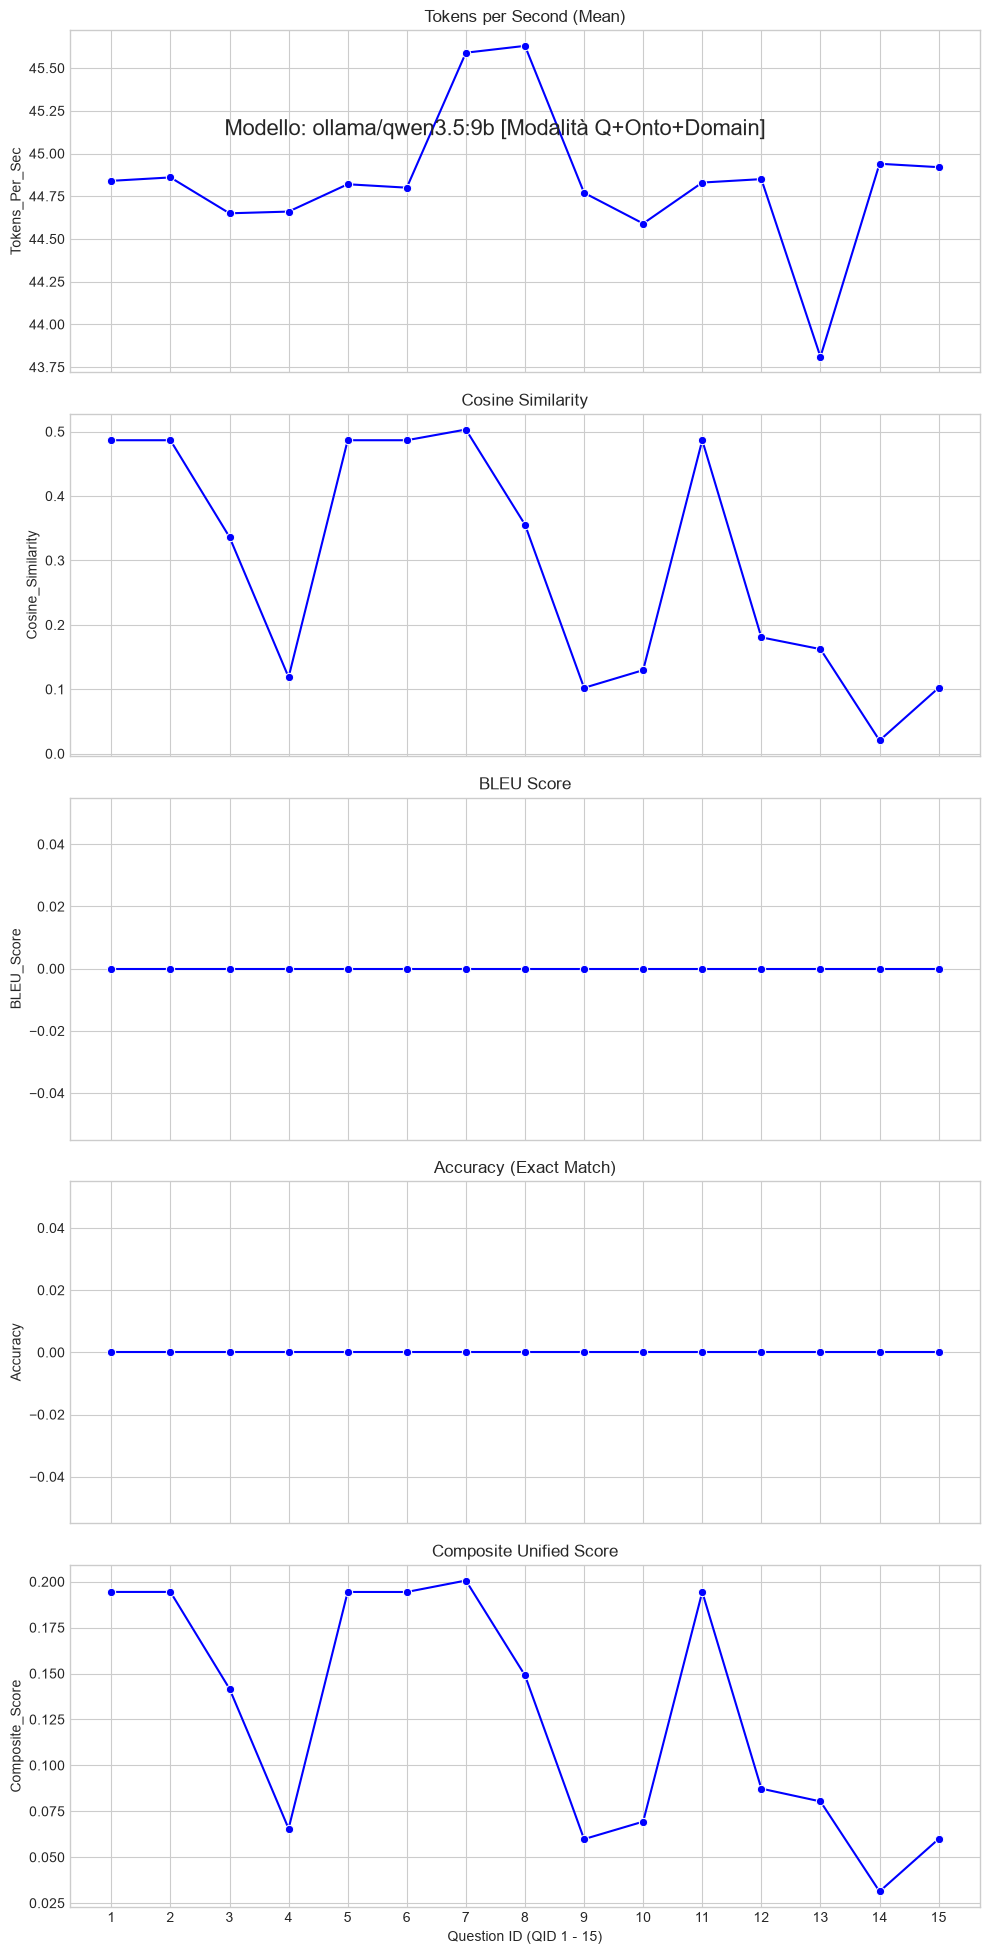

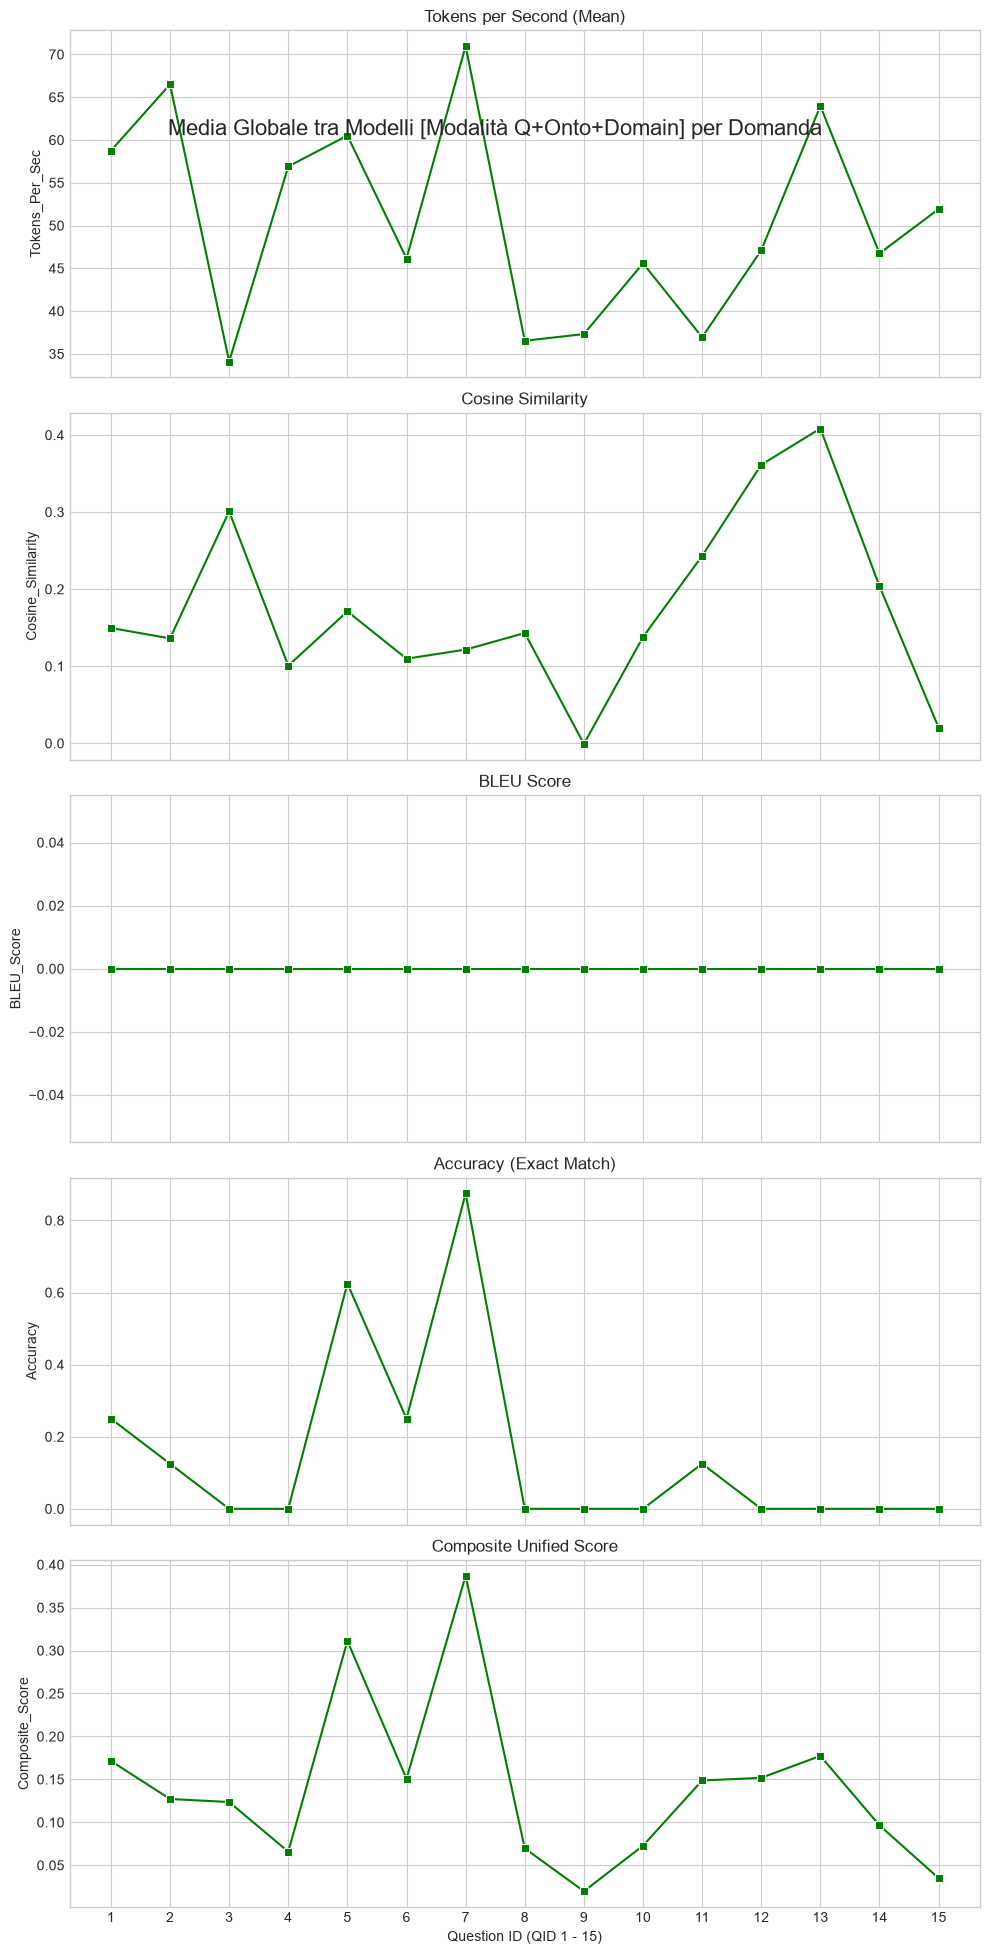

C:\Users\Patrizio\AppData\Local\Temp\ipykernel_18976\237227900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


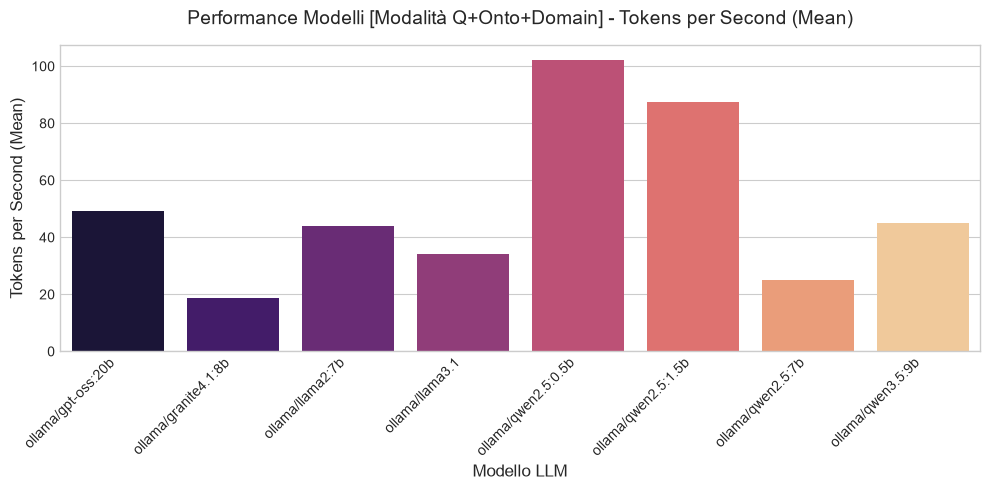

C:\Users\Patrizio\AppData\Local\Temp\ipykernel_18976\237227900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


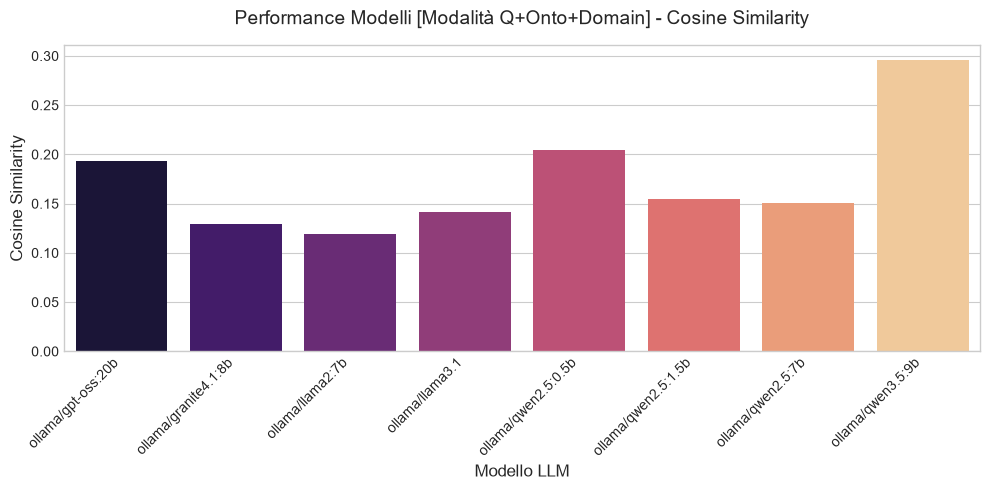

C:\Users\Patrizio\AppData\Local\Temp\ipykernel_18976\237227900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


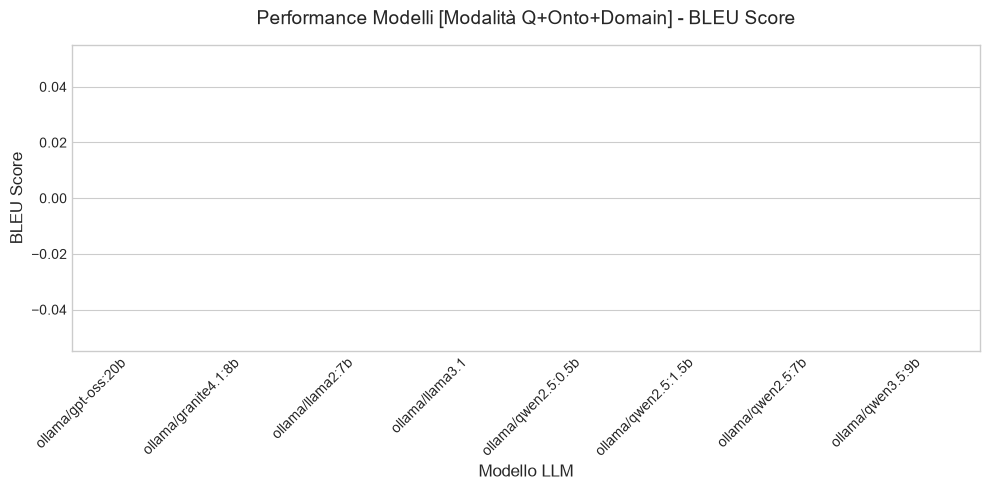

C:\Users\Patrizio\AppData\Local\Temp\ipykernel_18976\237227900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


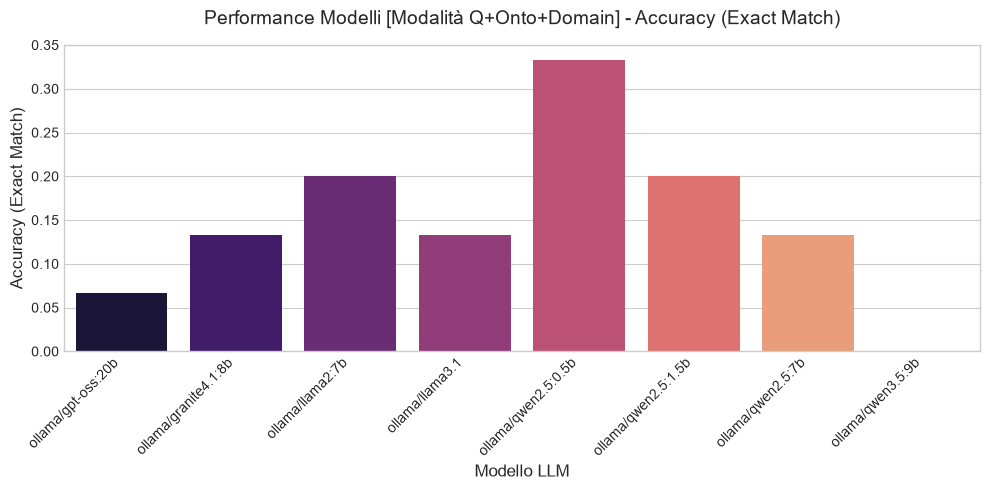

C:\Users\Patrizio\AppData\Local\Temp\ipykernel_18976\237227900.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


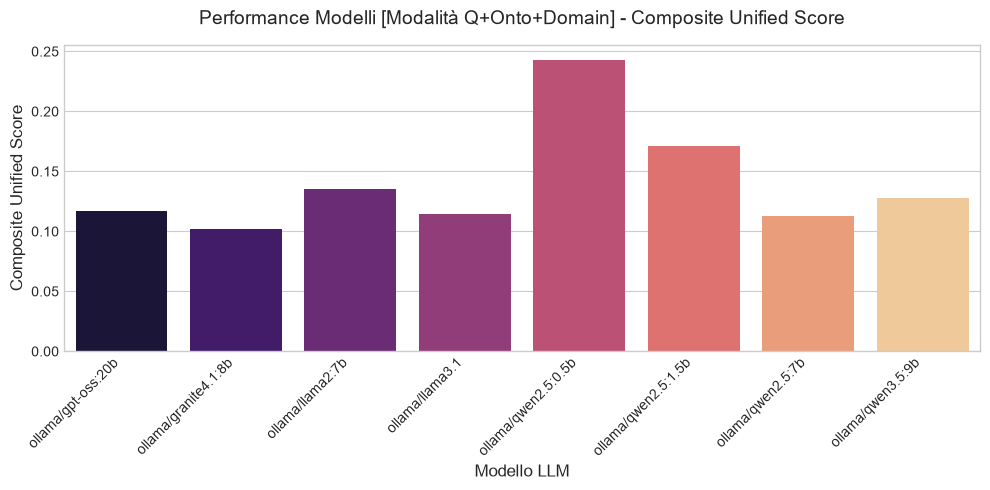

In [ ]:
# Modalità con l'ontologia
df_onto = df[df["Prompt_Mode"] == "Q+Onto+Domain"]

# 4.1 
for model in df_onto["Model"].unique():
    df_m = df_onto[df_onto["Model"] == model]
    
    fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)
    fig.suptitle(f"Modello: {model} [Modalità Q+Onto+Domain]", fontsize=16, y=0.92)
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[idx]
        sns.lineplot(
            data=df_m, x="QID", y=metric, marker="o", color="b", ax=ax
        )
        ax.set_title(title, fontsize=12)
        ax.set_ylabel(metric)
        ax.set_xticks(range(1, 16))
        
    plt.xlabel("Question ID (QID 1 - 15)")
    fig.subplots_adjust(top=0.88, hspace=0.4)
    plt.show()

# 4.2 
df_onto_avg_q = df_onto.groupby("QID")[["Tokens_Per_Sec", "Cosine_Similarity", "BLEU_Score", "Accuracy", "Composite_Score"]].mean().reset_index()

fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)
fig.suptitle("Media Globale tra Modelli [Modalità Q+Onto+Domain] per Domanda", fontsize=16, y=0.92)

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx]
    sns.lineplot(
        data=df_onto_avg_q, x="QID", y=metric, marker="s", color="g", ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks(range(1, 16))

plt.xlabel("Question ID (QID 1 - 15)")
fig.subplots_adjust(top=0.88, hspace=0.4)
plt.show()

# 4.3 
df_onto_avg_m = df_onto.groupby("Model")[["Tokens_Per_Sec", "Cosine_Similarity", "BLEU_Score", "Accuracy", "Composite_Score"]].mean().reset_index()

for metric, title in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_onto_avg_m, x="Model", y=metric, palette="magma"
    )
    plt.title(f"Performance Modelli [Modalità Q+Onto+Domain] - {title}", fontsize=14, pad=15)
    plt.xlabel("Modello LLM", fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()